In [42]:
import pandas as pd
import numpy as np
import os


In [43]:
excel_file_name = 'online_retail_II.xlsx'
project_dir = r'E:\github\c_online_retail_II'
file_path = os.path.join(project_dir, excel_file_name)

df = pd.read_excel(file_path)
df.head()
 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [44]:
# Remove cancelled invoices
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]

# Drop missing values
df = df.dropna()

# Keep only UK customers
df = df[df['Country'] == 'United Kingdom']

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove returns or invalid prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Calculate total price
df['TotalPrice'] = df['Quantity'] * df['Price']

print(f"Dataset shape after cleaning: {df.shape}")
df.head()


Dataset shape after cleaning: (370929, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [45]:
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {ref_date.date()}")


Reference date: 2010-12-10


In [46]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM shape: {rfm.shape}")
rfm.describe()


RFM shape: (3969, 4)


,CustomerID,Recency,Frequency,Monetary
count,3969.000000,3969.000000,3969.000000,3969.000000
mean,15561.406148,91.094986,4.437390,1868.167287
std,1582.099836,97.071763,7.531933,7380.830030
min,12346.000000,1.000000,1.000000,2.950000
25%,14201.000000,18.000000,1.000000,304.200000
50%,15577.000000,52.000000,2.000000,669.910000
75%,16941.000000,136.000000,5.000000,1655.640000
max,18287.000000,374.000000,155.000000,349164.350000


In [47]:
sample_customer = rfm.iloc[0]['CustomerID']
print(f"Sample customer ID: {sample_customer}")
rfm[rfm['CustomerID'] == sample_customer]
 

Sample customer ID: 12346.0


,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86


In [48]:
total_revenue = rfm['Monetary'].sum()
pareto_cutoff = total_revenue * 0.8

rfm_sorted = rfm.sort_values('Monetary', ascending=False)
rfm_sorted['CumulativeRevenue'] = rfm_sorted['Monetary'].cumsum()

top_customers = rfm_sorted[rfm_sorted['CumulativeRevenue'] <= pareto_cutoff]

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Customers contributing to 80% revenue: {len(top_customers)}")
print(f"Percentage of customers: {len(top_customers)/len(rfm)*100:.1f}%")
 

Total Revenue: £7,414,755.96
Customers contributing to 80% revenue: 1140
Percentage of customers: 28.7%


In [49]:
rfm_ranked = rfm.sort_values('Monetary', ascending=False)

top_20_count = int(len(rfm_ranked) * 0.2)
top_20_customers = rfm_ranked.head(top_20_count)

revenue_top_20 = top_20_customers['Monetary'].sum()
revenue_percentage = (revenue_top_20 / total_revenue) * 100

print(f"Top 20% customers count: {top_20_count}")
print(f"Revenue share: {revenue_percentage:.1f}%")
 

Top 20% customers count: 793
Revenue share: 71.9%


In [50]:
quantiles = rfm[['Recency', 'Frequency', 'Monetary']].quantile([0.25, 0.5, 0.75])
quantiles_dict = quantiles.to_dict()

quantiles, quantiles_dict
 

(      Recency  Frequency  Monetary
 0.25     18.0        1.0    304.20
 0.50     52.0        2.0    669.91
 0.75    136.0        5.0   1655.64,
 {'Recency': {0.25: 18.0, 0.5: 52.0, 0.75: 136.0},
  'Frequency': {0.25: 1.0, 0.5: 2.0, 0.75: 5.0},
  'Monetary': {0.25: 304.2, 0.5: 669.91, 0.75: 1655.64}})

In [51]:
def R_Score(x, p, d):
    # Recency: lower is better
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]:
        return 2
    else:
        return 1

def FM_Score(x, p, d):
    # Frequency & Monetary: higher is better
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]:
        return 3
    else:
        return 4


In [52]:
rfm_segmentation = rfm.copy()

rfm_segmentation['R_Quartile'] = rfm_segmentation['Recency'].apply(
    R_Score, args=('Recency', quantiles_dict)
)
rfm_segmentation['F_Quartile'] = rfm_segmentation['Frequency'].apply(
    FM_Score, args=('Frequency', quantiles_dict)
)
rfm_segmentation['M_Quartile'] = rfm_segmentation['Monetary'].apply(
    FM_Score, args=('Monetary', quantiles_dict)
)

rfm_segmentation.head()


,CustomerID,Recency,Frequency,Monetary,R_Quartile,F_Quartile,M_Quartile
0,12346.0,165,11,372.86,1,4,2
1,12608.0,40,1,415.79,3,1,2
2,12745.0,122,2,723.85,2,2,3
3,12746.0,176,1,254.55,1,1,1
4,12747.0,5,16,5080.53,4,4,4


In [53]:
rfm_segmentation['RFM_Score'] = (
    rfm_segmentation['R_Quartile'].astype(str) +
    rfm_segmentation['F_Quartile'].astype(str) +
    rfm_segmentation['M_Quartile'].astype(str)
)

rfm_segmentation[['RFM_Score']].value_counts().head()


RFM_Score
111          426
444          412
344          192
211          175
112          171
Name: count, dtype: int64

In [54]:
best_customers = rfm_segmentation[
    rfm_segmentation['RFM_Score'] == '444'
].sort_values('Monetary', ascending=False)

print(f"Best customers count (444): {len(best_customers)}")
print(f"Total revenue: £{best_customers['Monetary'].sum():,.2f}")

best_customers.head(10)


Best customers count (444): 412
Total revenue: £3,601,733.60


,CustomerID,Recency,Frequency,Monetary,R_Quartile,F_Quartile,M_Quartile,RFM_Score
3841,18102.0,1,89,349164.35,4,4,4,444
636,13694.0,9,94,131443.19,4,4,4,444
3403,17511.0,3,31,84541.17,4,4,4,444
1623,15061.0,3,86,83284.38,4,4,4,444
2790,16684.0,15,27,80489.21,4,4,4,444
2839,16754.0,8,29,65500.07,4,4,4,444
3723,17949.0,7,74,60117.60,4,4,4,444
205,13089.0,4,109,57912.03,4,4,4,444
1805,15311.0,1,121,56003.26,4,4,4,444
3364,17450.0,3,7,52422.30,4,4,4,444


In [55]:
print("Customer Segments Summary")
print("-" * 40)

segments = {
    'Best Customers (444)': '444',
    'Almost Lost (244)': '244',
    'Lost Customers (144)': '144',
    'Lost Cheap Customers (111)': '111'
}

for name, code in segments.items():
    count = len(rfm_segmentation[rfm_segmentation['RFM_Score'] == code])
    print(f"{name}: {count}")

print(f"Loyal Customers (F=4): {len(rfm_segmentation[rfm_segmentation['F_Quartile'] == 4])}")
print(f"Big Spenders (M=4): {len(rfm_segmentation[rfm_segmentation['M_Quartile'] == 4])}")


Customer Segments Summary
----------------------------------------
Best Customers (444): 412
Almost Lost (244): 98
Lost Customers (144): 17
Lost Cheap Customers (111): 426
Loyal Customers (F=4): 884
Big Spenders (M=4): 992


In [56]:
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']].copy()
print(f"Clustering data shape: {rfm_data.shape}")
rfm_data.head()


Clustering data shape: (3969, 3)


,Recency,Frequency,Monetary
0,165,11,372.86
1,40,1,415.79
2,122,2,723.85
3,176,1,254.55
4,5,16,5080.53


In [57]:
rfm_log = pd.DataFrame({
    'Recency_log': np.log(rfm_data['Recency'] + 0.1),
    'Frequency_log': np.log(rfm_data['Frequency'] + 0.1),
    'Monetary_log': np.log(rfm_data['Monetary'] + 0.1)
})

rfm_log.head()


,Recency_log,Frequency_log,Monetary_log
0,5.106551,2.406945,5.921471
1,3.691376,0.095310,6.030421
2,4.804840,0.741937,6.584722
3,5.171052,0.095310,5.539890
4,1.629241,2.778819,8.533191


In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

matrix = rfm_log.values
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = kmeans.fit_predict(matrix)
    silhouette_scores[k] = silhouette_score(matrix, labels)
    print(f"k={k}: silhouette={silhouette_scores[k]:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")


k=2: silhouette=0.4081
k=3: silhouette=0.3212
k=4: silhouette=0.3399
k=5: silhouette=0.3251
k=6: silhouette=0.3208
k=7: silhouette=0.3195
k=8: silhouette=0.3035
k=9: silhouette=0.2936
k=10: silhouette=0.2887

Best k: 2


In [59]:
kmeans = KMeans(n_clusters=best_k, n_init=100, random_state=42)
clusters = kmeans.fit_predict(matrix)

rfm_segmentation['Cluster'] = clusters

print(f"Final Silhouette Score: {silhouette_score(matrix, clusters):.4f}")
rfm_segmentation[['Cluster']].value_counts()


Final Silhouette Score: 0.4081


Cluster
0          2349
1          1620
Name: count, dtype: int64

In [60]:
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.decomposition import PCA

scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'PowerTransformer': PowerTransformer()
}

best_score = 0

for name, scaler in scalers.items():
    try:
        scaled = scaler.fit_transform(matrix)
        pca = PCA(n_components=3, random_state=42)
        pca_data = pca.fit_transform(scaled)

        labels = KMeans(n_clusters=best_k, n_init=50, random_state=42).fit_predict(pca_data)
        score = silhouette_score(pca_data, labels)

        print(f"{name} + PCA: silhouette={score:.4f}, explained_var={pca.explained_variance_ratio_.sum():.2f}")

        if score > best_score:
            best_score = score
            best_pca_data = pca_data
            best_clusters = labels
    except Exception as e:
        print(f"{name} failed: {e}")

print(f"\nBest PCA-based silhouette: {best_score:.4f}")


StandardScaler + PCA: silhouette=0.4233, explained_var=1.00
RobustScaler + PCA: silhouette=0.4168, explained_var=1.00
PowerTransformer + PCA: silhouette=0.4251, explained_var=1.00

Best PCA-based silhouette: 0.4251


In [61]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

algorithms = {
    'KMeans': KMeans(n_clusters=best_k, random_state=42),
    'GaussianMixture': GaussianMixture(n_components=best_k, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=best_k),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

results = {}

for name, algo in algorithms.items():
    try:
        labels = algo.fit_predict(best_pca_data)
        if len(set(labels)) > 1:
            score = silhouette_score(best_pca_data, labels)
            results[name] = score
            print(f"{name}: silhouette={score:.4f}")
    except Exception as e:
        print(f"{name} error: {e}")

if results:
    best_algo = max(results, key=results.get)
    print(f"\nBest algorithm: {best_algo} ({results[best_algo]:.4f})")


KMeans: silhouette=0.4248
GaussianMixture: silhouette=0.4013
Agglomerative: silhouette=0.4040
DBSCAN: silhouette=0.3933

Best algorithm: KMeans (0.4248)


In [62]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(matrix)

clean_matrix = matrix[labels == 1]

print(f"Outliers removed: {len(matrix) - len(clean_matrix)}")

kmeans_clean = KMeans(n_clusters=best_k, random_state=42, n_init=50)
clean_clusters = kmeans_clean.fit_predict(clean_matrix)

print(f"Silhouette (clean data): {silhouette_score(clean_matrix, clean_clusters):.4f}")


Outliers removed: 199
Silhouette (clean data): 0.4048


In [63]:
rfm_df = rfm.copy()
rfm_df['Cluster'] = best_clusters
rfm_df.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,0
1,12608.0,40,1,415.79,1
2,12745.0,122,2,723.85,1
3,12746.0,176,1,254.55,1
4,12747.0,5,16,5080.53,0


In [64]:
cluster_summary = rfm_df.groupby('Cluster').agg(
    Customer_Count=('Monetary', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)

cluster_summary['Revenue_Share_%'] = (
    cluster_summary['Total_Revenue'] / cluster_summary['Total_Revenue'].sum() * 100
).round(1)

cluster_summary


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
Cluster,,,,,,
0,1992,37.92,7.41,3335.78,6644877.28,89.6
1,1977,144.67,1.44,389.42,769878.68,10.4


In [65]:
segment_info = {}

for cluster, row in cluster_summary.iterrows():
    if row.Avg_Recency < 60 and row.Avg_Frequency > 10:
        name = "VIP Customers"
        strategy = "Loyalty program, exclusive offers, priority service"
    elif row.Avg_Recency < 120 and row.Avg_Frequency > 5:
        name = "Loyal Customers"
        strategy = "Personalized offers, email campaigns"
    elif row.Avg_Recency > 200:
        name = "At-Risk Customers"
        strategy = "Win-back campaign, discounts, reminders"
    elif row.Avg_Frequency < 3:
        name = "New Customers"
        strategy = "Onboarding, first repeat purchase incentives"
    else:
        name = "Regular Customers"
        strategy = "Cross-sell & upsell strategies"

    segment_info[cluster] = {
        'Segment': name,
        'Strategy': strategy
    }

segment_info


{0: {'Segment': 'Loyal Customers',
  'Strategy': 'Personalized offers, email campaigns'},
 1: {'Segment': 'New Customers',
  'Strategy': 'Onboarding, first repeat purchase incentives'}}

In [66]:
rfm_df['Segment'] = rfm_df['Cluster'].map(lambda x: segment_info[x]['Segment'])
rfm_df['Strategy'] = rfm_df['Cluster'].map(lambda x: segment_info[x]['Strategy'])

rfm_df[['Segment', 'Strategy']].head()


,Segment,Strategy
0,Loyal Customers,"Personalized offers, email campaigns"
1,New Customers,"Onboarding, first repeat purchase incentives"
2,New Customers,"Onboarding, first repeat purchase incentives"
3,New Customers,"Onboarding, first repeat purchase incentives"
4,Loyal Customers,"Personalized offers, email campaigns"


In [67]:
from datetime import datetime

def executive_summary(rfm_df, segment_info):
    total_customers = len(rfm_df)
    total_revenue = rfm_df['Monetary'].sum()

    summary = f"""
Customer Segmentation Executive Report
Generated on: {datetime.now().strftime('%Y-%m-%d')}

Total Customers: {total_customers:,}
Total Revenue: £{total_revenue:,.0f}

Segment Overview:
"""

    for cluster, info in segment_info.items():
        segment_data = rfm_df[rfm_df['Cluster'] == cluster]
        revenue = segment_data['Monetary'].sum()

        summary += f"""
- {info['Segment']}
  Customers: {len(segment_data):,}
  Revenue Share: {revenue / total_revenue * 100:.1f}%
  Strategy: {info['Strategy']}
"""

    return summary

report = executive_summary(rfm_df, segment_info)
print(report)



Customer Segmentation Executive Report
Generated on: 2026-02-04

Total Customers: 3,969
Total Revenue: £7,414,756

Segment Overview:

- Loyal Customers
  Customers: 1,992
  Revenue Share: 89.6%
  Strategy: Personalized offers, email campaigns

- New Customers
  Customers: 1,977
  Revenue Share: 10.4%
  Strategy: Onboarding, first repeat purchase incentives



In [68]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rfm_scored = rfm_df.copy()
rfm_scored['R_Score'] = 100 - scaler.fit_transform(rfm_scored[['Recency']])
rfm_scored['F_Score'] = scaler.fit_transform(rfm_scored[['Frequency']])
rfm_scored['M_Score'] = scaler.fit_transform(rfm_scored[['Monetary']])

rfm_scored['Total_Score'] = (
    0.3 * rfm_scored['R_Score'] +
    0.4 * rfm_scored['F_Score'] +
    0.3 * rfm_scored['M_Score']
)

rfm_scored['Tier'] = pd.cut(
    rfm_scored['Total_Score'],
    bins=[0, 40, 60, 80, 100],
    labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

rfm_scored[['Total_Score', 'Tier']].head()


,Total_Score,Tier
0,29.894388,Bronze
1,29.968987,Bronze
2,29.905898,Bronze
3,29.859466,Bronze
4,30.040107,Bronze


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df_churn = rfm_df.copy()
df_churn['Churn_Risk'] = (
    (df_churn['Recency'] > 120) &
    (df_churn['Frequency'] < df_churn['Frequency'].median())
).astype(int)

X = df_churn[['Recency', 'Frequency', 'Monetary']]
y = df_churn['Churn_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

df_churn['Churn_Probability'] = model.predict_proba(X)[:, 1]

df_churn[['Churn_Probability']].describe()


,Churn_Probability
count,3969.000000
mean,0.167080
std,0.370578
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [70]:
clv = rfm_df.copy()
clv['CLV'] = clv['Monetary'] * 0.3  # gross margin assumption

clv['CLV_Level'] = pd.qcut(
    clv['CLV'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

clv[['CLV', 'CLV_Level']].head()


,CLV,CLV_Level
0,111.858,Medium
1,124.737,Medium
2,217.155,High
3,76.365,Low
4,1524.159,Very High


In [ ]:
output_dir = r'E:\github\c_online_retail_II\output'
os.makedirs(output_dir, exist_ok=True)

final_output = rfm_df.copy()

final_output = final_output.merge(
    rfm_scored[['Total_Score', 'Tier']],
    left_index=True,
    right_index=True
)

final_output = final_output.merge(
    df_churn[['Churn_Probability']],
    left_index=True,
    right_index=True
)

final_output = final_output.merge(
    clv[['CLV', 'CLV_Level']],
    left_index=True,
    right_index=True
)

final_output.reset_index(inplace=True)

file_path = os.path.join(output_dir, 'customer_segmentation_final.xlsx')
final_output.to_excel(file_path, index=False)

print(f"✅ File saved successfully at:\n{file_path}")


In [71]:
===================================================

SyntaxError: invalid syntax (4245300308.py, line 1)

In [ ]:
excel_file_name = 'online_retail_II.xlsx'
project_dir = r'E:\github\c_online_retail_II'
file_path = os.path.join(project_dir, excel_file_name)

df = pd.read_excel(file_path)

In [ ]:
# Drop cancelled transactions
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]

# Drop transactions with missing values
df.dropna(inplace=True)

# Filter for United Kingdom
df = df[df['Country'] == 'United Kingdom']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate TotalPrice
df['TotalPrice'] = df['Quantity'] * df['Price']

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# Remove negative prices if any
df = df[df['Price'] > 0]

print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Dataset shape after cleaning: (370929, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
# Set reference date (one day after last purchase)
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                 # Frequency
    'TotalPrice': 'sum'                                   # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM shape: {rfm.shape}")
print(f"Number of customers: {rfm['CustomerID'].nunique()}")
print("\nRFM Statistics:")
rfm.describe()


RFM shape: (3969, 4)
Number of customers: 3969

RFM Statistics:


,CustomerID,Recency,Frequency,Monetary
count,3969.000000,3969.000000,3969.000000,3969.000000
mean,15561.406148,91.094986,4.437390,1868.167287
std,1582.099836,97.071763,7.531933,7380.830030
min,12346.000000,1.000000,1.000000,2.950000
25%,14201.000000,18.000000,1.000000,304.200000
50%,15577.000000,52.000000,2.000000,669.910000
75%,16941.000000,136.000000,5.000000,1655.640000
max,18287.000000,374.000000,155.000000,349164.350000


In [ ]:

# Set reference date (one day after last purchase)
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                 # Frequency
    'TotalPrice': 'sum'                                   # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']



In [ ]:
# Calculate current date (last purchase date in data)
now = df['InvoiceDate'].max().date()
print(f"Last date in dataset: {now}")
print(f"Dataset range: {df['InvoiceDate'].min().date()} to {now}")

Last date in dataset: 2010-12-09
Dataset range: 2009-12-01 to 2010-12-09


In [ ]:
# Group by Customer ID to find last purchase date
recency_df = df.groupby('Customer ID', as_index=False)['InvoiceDate'].max()
recency_df.columns = ['CustomerID', 'LastPurchaseDate']
recency_df['LastPurchaseDate'] = recency_df['LastPurchaseDate'].dt.date
recency_df.head()

,CustomerID,LastPurchaseDate
0,12346.0,2010-06-28
1,12608.0,2010-10-31
2,12745.0,2010-08-10
3,12746.0,2010-06-17
4,12747.0,2010-12-05


In [ ]:
# Calculate Recency in days
recency_df['Recency'] = recency_df['LastPurchaseDate'].apply(
    lambda x: (now - x).days if pd.notnull(x) else np.nan
)

# Drop the LastPurchaseDate column
recency_df = recency_df[['CustomerID', 'Recency']]

print(f"Recency statistics:")
print(recency_df['Recency'].describe())
recency_df.head()


Recency statistics:
count    3969.000000
mean       90.095742
std        97.072657
min         0.000000
25%        17.000000
50%        51.000000
75%       135.000000
max       373.000000
Name: Recency, dtype: float64


,CustomerID,Recency
0,12346.0,164
1,12608.0,39
2,12745.0,121
3,12746.0,175
4,12747.0,4


In [ ]:
# Remove duplicate invoices for same customer (keep first occurrence)
retail_clean = df.drop_duplicates(
    subset=['Invoice', 'Customer ID'], 
    keep='first'
)

# Calculate Frequency (number of unique invoices per customer)
frequency_df = retail_clean.groupby('Customer ID', as_index=False)['Invoice'].nunique()
frequency_df.columns = ['CustomerID', 'Frequency']

print(f"Frequency statistics:")
print(frequency_df['Frequency'].describe())
frequency_df.head()

Frequency statistics:
count    3969.000000
mean        4.437390
std         7.531933
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       155.000000
Name: Frequency, dtype: float64


,CustomerID,Frequency
0,12346.0,11
1,12608.0,1
2,12745.0,2
3,12746.0,1
4,12747.0,16


In [ ]:

df['TotalCost'] = df['TotalPrice']

In [ ]:
# Calculate total monetary value per customer
monetary_df = df.groupby('Customer ID', as_index=False).agg({
    'TotalPrice': 'sum'
})
monetary_df.columns = ['CustomerID', 'Monetary']

print(f"Monetary statistics:")
print(monetary_df['Monetary'].describe())
monetary_df.head()

Monetary statistics:
count      3969.000000
mean       1868.167287
std        7380.830030
min           2.950000
25%         304.200000
50%         669.910000
75%        1655.640000
max      349164.350000
Name: Monetary, dtype: float64


,CustomerID,Monetary
0,12346.0,372.86
1,12608.0,415.79
2,12745.0,723.85
3,12746.0,254.55
4,12747.0,5080.53


In [ ]:
# Merge Recency and Frequency
temp_df = recency_df.merge(frequency_df, on='CustomerID', how='inner')
print(f"Merged Recency-Frequency shape: {temp_df.shape}")
temp_df.head()

Merged Recency-Frequency shape: (3969, 3)


,CustomerID,Recency,Frequency
0,12346.0,164,11
1,12608.0,39,1
2,12745.0,121,2
3,12746.0,175,1
4,12747.0,4,16


In [ ]:

# Merge with Monetary to create final RFM dataframe
rfm_df = temp_df.merge(monetary_df, on='CustomerID', how='inner')
rfm_df.set_index('CustomerID', inplace=True)

print(f"Final RFM dataframe shape: {rfm_df.shape}")
print(f"\nMissing values:")
print(rfm_df.isnull().sum())
print(f"\nRFM Statistics:")
rfm_df.describe()

Final RFM dataframe shape: (3969, 3)

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64

RFM Statistics:


,Recency,Frequency,Monetary
count,3969.000000,3969.000000,3969.000000
mean,90.095742,4.437390,1868.167287
std,97.072657,7.531933,7380.830030
min,0.000000,1.000000,2.950000
25%,17.000000,1.000000,304.200000
50%,51.000000,2.000000,669.910000
75%,135.000000,5.000000,1655.640000
max,373.000000,155.000000,349164.350000


In [ ]:
# بررسی یک مشتری نمونه
sample_customer = rfm_df.index[0]
print(f"Sample customer {sample_customer} data:")
print(rfm_df.loc[sample_customer])

#از دیتای اصلی بررسی کنید:
customer_id = 12346.0
if customer_id in df['Customer ID'].values:
    print(f"\nOriginal transactions for customer {customer_id}:")
    print(df[df['Customer ID'] == customer_id].head())
else:
    print(f"Customer {customer_id} not found in cleaned data")


Sample customer 12346.0 data:
Recency      164.00
Frequency     11.00
Monetary     372.86
Name: 12346.0, dtype: float64

Original transactions for customer 12346.0:
      Invoice StockCode              Description  Quantity  \
27994  491725   TEST001  This is a test product.        10   
28251  491742   TEST001  This is a test product.         5   
28254  491744   TEST001  This is a test product.         5   
39398  492718   TEST001  This is a test product.         5   
39411  492722   TEST002  This is a test product.         1   

              InvoiceDate  Price  Customer ID         Country  TotalPrice  \
27994 2009-12-14 08:34:00    4.5      12346.0  United Kingdom        45.0   
28251 2009-12-14 11:00:00    4.5      12346.0  United Kingdom        22.5   
28254 2009-12-14 11:02:00    4.5      12346.0  United Kingdom        22.5   
39398 2009-12-18 10:47:00    4.5      12346.0  United Kingdom        22.5   
39411 2009-12-18 10:55:00    1.0      12346.0  United Kingdom         1.0   


In [ ]:
# Calculate 80% of total revenue
total_revenue = rfm_df['Monetary'].sum()
pareto_cutoff = total_revenue * 0.8
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"80% of total revenue: £{pareto_cutoff:,.2f}")

# Sort customers by Monetary value descending
rfm_sorted = rfm_df.sort_values('Monetary', ascending=False)
rfm_sorted['CumulativeRevenue'] = rfm_sorted['Monetary'].cumsum()

# Find how many customers contribute to 80% of revenue
top_customers = rfm_sorted[rfm_sorted['CumulativeRevenue'] <= pareto_cutoff]
print(f"\nNumber of customers contributing to 80% revenue: {len(top_customers)}")
print(f"Percentage of customers: {len(top_customers)/len(rfm_df)*100:.1f}%")



Total Revenue: £7,414,755.96
80% of total revenue: £5,931,804.77

Number of customers contributing to 80% revenue: 1140
Percentage of customers: 28.7%


In [ ]:
# Rank customers by Monetary value
customers_rank = rfm_df.copy()
customers_rank['RevenueRank'] = customers_rank['Monetary'].rank(ascending=False, method='first')
customers_rank = customers_rank.sort_values('RevenueRank')

print("Top 10 customers by revenue:")
print(customers_rank.head(10))
print(f"\nTotal customers: {len(customers_rank)}")

Top 10 customers by revenue:
            Recency  Frequency   Monetary  RevenueRank
CustomerID                                            
18102.0           0         89  349164.35          1.0
13694.0           8         94  131443.19          2.0
17511.0           2         31   84541.17          3.0
15061.0           2         86   83284.38          4.0
16684.0          14         27   80489.21          5.0
16754.0           7         29   65500.07          6.0
17949.0           6         74   60117.60          7.0
13089.0           3        109   57912.03          8.0
15311.0           0        121   56003.26          9.0
17450.0           2          7   52422.30         10.0

Total customers: 3969


In [ ]:
# Calculate top 20% customers
total_customers = len(customers_rank)
top_20_count = int(total_customers * 0.2)

print(f"Total customers: {total_customers}")
print(f"Top 20% customers count: {top_20_count}")

# Calculate revenue from top 20% customers
top_20_customers = customers_rank.head(top_20_count)
revenue_top_20 = top_20_customers['Monetary'].sum()
revenue_percentage = (revenue_top_20 / total_revenue) * 100

print(f"\nRevenue from top 20% customers: £{revenue_top_20:,.2f}")
print(f"Percentage of total revenue: {revenue_percentage:.1f}%")

# Pareto check
if revenue_percentage > 70:
    print("✓ Pareto principle (80/20 rule) is observed")
else:
    print("⚠ Pareto principle is not strongly observed")

Total customers: 3969
Top 20% customers count: 793

Revenue from top 20% customers: £5,331,960.96
Percentage of total revenue: 71.9%
✓ Pareto principle (80/20 rule) is observed


In [ ]:
# محاسبه کوانتیل‌ها
quantiles = rfm_df.quantile(q=[0.25, 0.5, 0.75])
print("Quantiles for RFM metrics:")
print(quantiles)
print("\nQuantiles as dictionary:")
quantiles_dict = quantiles.to_dict()
print(quantiles_dict)

Quantiles for RFM metrics:
      Recency  Frequency  Monetary
0.25     17.0        1.0    304.20
0.50     51.0        2.0    669.91
0.75    135.0        5.0   1655.64

Quantiles as dictionary:
{'Recency': {0.25: 17.0, 0.5: 51.0, 0.75: 135.0}, 'Frequency': {0.25: 1.0, 0.5: 2.0, 0.75: 5.0}, 'Monetary': {0.25: 304.2, 0.5: 669.91, 0.75: 1655.64}}


In [ ]:
# تعریف توابع امتیازدهی RFM
def R_Score(x, p, d):
    """امتیازدهی Recency (هرچه کمتر بهتر)"""
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1

def FM_Score(x, p, d):
    """امتیازدهی Frequency و Monetary (هرچه بیشتر بهتر)"""
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4

# ایجاد RFM segmentation
rfm_segmentation = rfm_df.copy()

# اعمال امتیازدهی
rfm_segmentation['R_Quartile'] = rfm_segmentation['Recency'].apply(R_Score, args=('Recency', quantiles_dict))
rfm_segmentation['F_Quartile'] = rfm_segmentation['Frequency'].apply(FM_Score, args=('Frequency', quantiles_dict))
rfm_segmentation['M_Quartile'] = rfm_segmentation['Monetary'].apply(FM_Score, args=('Monetary', quantiles_dict))

print("RFM Segmentation (first 5 rows):")
print(rfm_segmentation.head())
print(f"\nTotal customers segmented: {len(rfm_segmentation)}")

RFM Segmentation (first 5 rows):
            Recency  Frequency  Monetary  R_Quartile  F_Quartile  M_Quartile
CustomerID                                                                  
12346.0         164         11    372.86           1           4           2
12608.0          39          1    415.79           3           1           2
12745.0         121          2    723.85           2           2           3
12746.0         175          1    254.55           1           1           1
12747.0           4         16   5080.53           4           4           4

Total customers segmented: 3969


In [ ]:
# ایجاد RFM Score ترکیبی
rfm_segmentation['RFM_Score'] = (rfm_segmentation['R_Quartile'].astype(str) + 
                                 rfm_segmentation['F_Quartile'].astype(str) + 
                                 rfm_segmentation['M_Quartile'].astype(str))

print("RFM Scores created:")
print(rfm_segmentation[['R_Quartile', 'F_Quartile', 'M_Quartile', 'RFM_Score']].head())


RFM Scores created:
            R_Quartile  F_Quartile  M_Quartile RFM_Score
CustomerID                                              
12346.0              1           4           2       142
12608.0              3           1           2       312
12745.0              2           2           3       223
12746.0              1           1           1       111
12747.0              4           4           4       444


In [ ]:
# تحلیل مشتریان برتر (444 = بهترین مشتریان)
best_customers = rfm_segmentation[rfm_segmentation['RFM_Score'] == '444'].sort_values('Monetary', ascending=False)

print(f"تعداد بهترین مشتریان (RFM=444): {len(best_customers)}")
print(f"درآمد کل بهترین مشتریان: £{best_customers['Monetary'].sum():,.2f}")
print("\nTop 10 Best Customers:")
print(best_customers.head(10))

تعداد بهترین مشتریان (RFM=444): 412
درآمد کل بهترین مشتریان: £3,601,733.60

Top 10 Best Customers:
            Recency  Frequency   Monetary  R_Quartile  F_Quartile  M_Quartile  \
CustomerID                                                                      
18102.0           0         89  349164.35           4           4           4   
13694.0           8         94  131443.19           4           4           4   
17511.0           2         31   84541.17           4           4           4   
15061.0           2         86   83284.38           4           4           4   
16684.0          14         27   80489.21           4           4           4   
16754.0           7         29   65500.07           4           4           4   
17949.0           6         74   60117.60           4           4           4   
13089.0           3        109   57912.03           4           4           4   
15311.0           0        121   56003.26           4           4           4   
17450.0   

In [ ]:
# محاسبه آمارهای کلیدی
print("📊 آمارهای کلیدی مشتریان:")
print("=" * 50)
print(f"Best Customers (RFM=444): {len(rfm_segmentation[rfm_segmentation['RFM_Score'] == '444'])}")
print(f"Loyal Customers (F=4): {len(rfm_segmentation[rfm_segmentation['F_Quartile'] == 4])}")
print(f"Big Spenders (M=4): {len(rfm_segmentation[rfm_segmentation['M_Quartile'] == 4])}")
print(f"Almost Lost (RFM=244): {len(rfm_segmentation[rfm_segmentation['RFM_Score'] == '244'])}")
print(f"Lost Customers (RFM=144): {len(rfm_segmentation[rfm_segmentation['RFM_Score'] == '144'])}")
print(f"Lost Cheap Customers (RFM=111): {len(rfm_segmentation[rfm_segmentation['RFM_Score'] == '111'])}")
print("=" * 50)

📊 آمارهای کلیدی مشتریان:
Best Customers (RFM=444): 412
Loyal Customers (F=4): 884
Big Spenders (M=4): 992
Almost Lost (RFM=244): 98
Lost Customers (RFM=144): 17
Lost Cheap Customers (RFM=111): 426


In [ ]:
# ایجاد داده خالص برای Clustering
rfm_data = rfm_df.copy()

print("RFM Data for Clustering:")
print(rfm_data.head())
print(f"\nData shape: {rfm_data.shape}")




# ========== rfm_data = rfm_df.copy()  جرا اينجا كبي كرفتيم براي جي؟

RFM Data for Clustering:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         164         11    372.86
12608.0          39          1    415.79
12745.0         121          2    723.85
12746.0         175          1    254.55
12747.0           4         16   5080.53

Data shape: (3969, 3)


Correlation Matrix:
            Recency  Frequency  Monetary
Recency    1.000000  -0.266443 -0.133314
Frequency -0.266443   1.000000  0.611307
Monetary  -0.133314   0.611307  1.000000


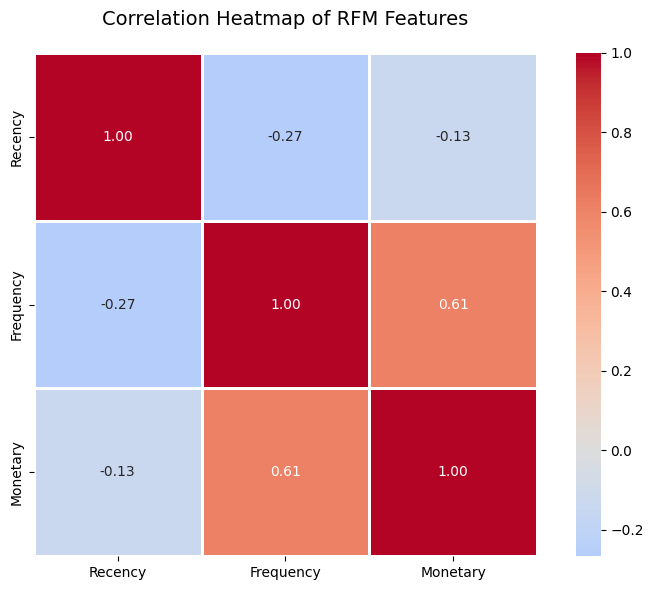

In [ ]:
# محاسبه همبستگی
correlation_matrix = rfm_data.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, linecolor='white')
plt.title('Correlation Heatmap of RFM Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Scatter Matrix of RFM Features:


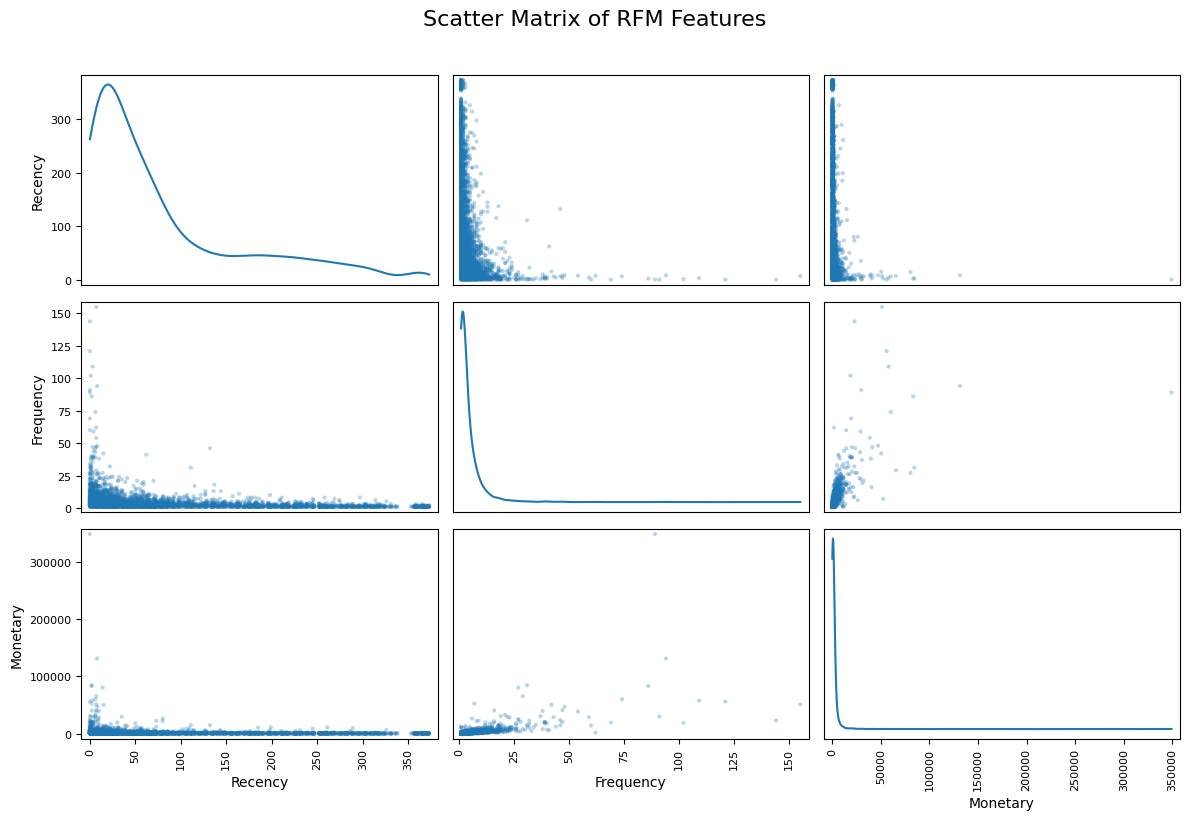

In [ ]:
# Scatter Matrix
print("Scatter Matrix of RFM Features:")
scatter_matrix(rfm_data, alpha=0.3, figsize=(12, 8), diagonal='kde')
plt.suptitle('Scatter Matrix of RFM Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Log Transformed Data (first 5 rows):
            Recency_log  Frequency_log  Monetary_log
CustomerID                                          
12346.0        5.100476       2.406945      5.921471
12608.0        3.666122       0.095310      6.030421
12745.0        4.796617       0.741937      6.584722
12746.0        5.165357       0.095310      5.539890
12747.0        1.410987       2.778819      8.533191

Scatter Matrix of Log-Transformed Features:


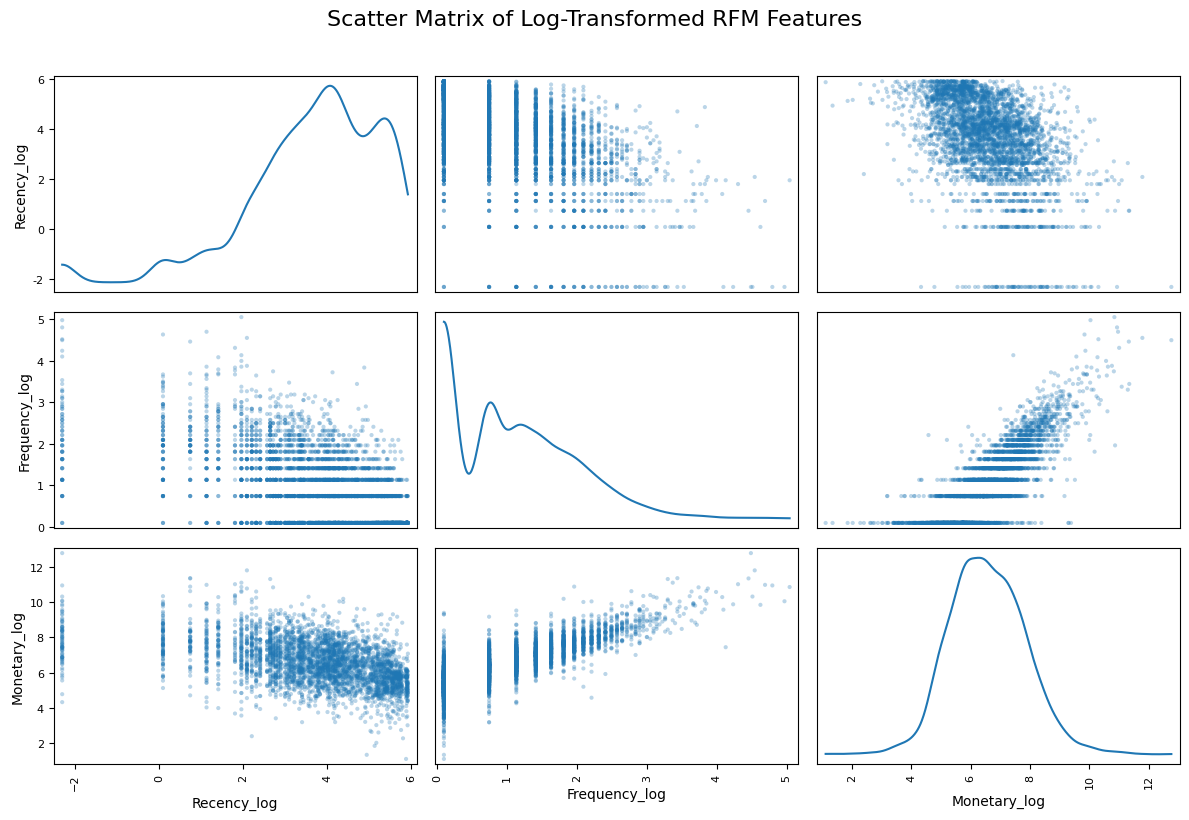

In [ ]:
# اعمال Log Transformation برای کاهش skewness
rfm_log = pd.DataFrame()
rfm_log['Recency_log'] = np.log(rfm_data['Recency'] + 0.1)  # اضافه کردن 0.1 برای اجتناب از log(0)
rfm_log['Frequency_log'] = np.log(rfm_data['Frequency'] + 0.1)
rfm_log['Monetary_log'] = np.log(rfm_data['Monetary'] + 0.1)

print("Log Transformed Data (first 5 rows):")
print(rfm_log.head())

# Scatter Matrix داده‌های log شده
print("\nScatter Matrix of Log-Transformed Features:")
scatter_matrix(rfm_log, alpha=0.3, figsize=(12, 8), diagonal='kde')
plt.suptitle('Scatter Matrix of Log-Transformed RFM Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Correlation Matrix of Log-Transformed Data:
               Recency_log  Frequency_log  Monetary_log
Recency_log       1.000000      -0.530966     -0.454997
Frequency_log    -0.530966       1.000000      0.832001
Monetary_log     -0.454997       0.832001      1.000000


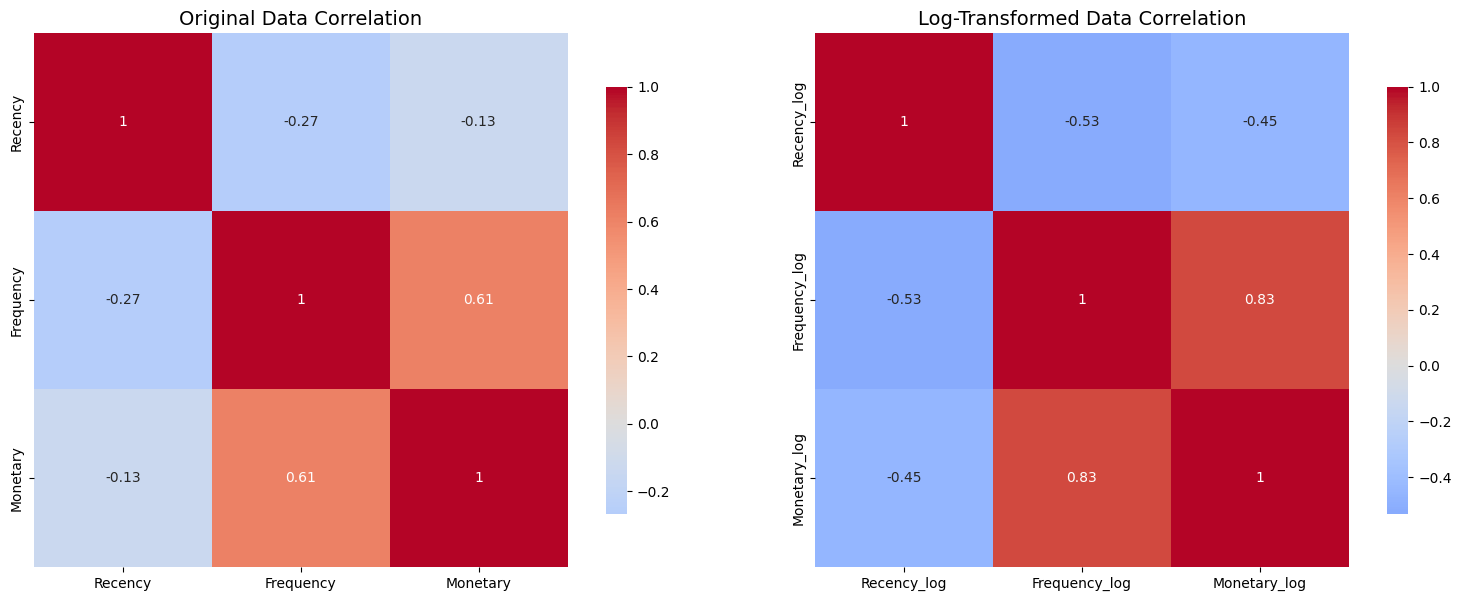

In [ ]:
# تحلیل همبستگی داده‌های log شده
log_corr = rfm_log.corr()
print("Correlation Matrix of Log-Transformed Data:")
print(log_corr)

# مقایسه Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap داده‌های اصلی
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[0], square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Original Data Correlation', fontsize=14)

# Heatmap داده‌های log شده
sns.heatmap(log_corr, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1], square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Log-Transformed Data Correlation', fontsize=14)

plt.tight_layout()
plt.show()

Silhouette Scores for different numbers of clusters:
n_clusters = 2: Silhouette Score = 0.4115
n_clusters = 3: Silhouette Score = 0.3592
n_clusters = 4: Silhouette Score = 0.3293
n_clusters = 5: Silhouette Score = 0.3344
n_clusters = 6: Silhouette Score = 0.3274
n_clusters = 7: Silhouette Score = 0.3238
n_clusters = 8: Silhouette Score = 0.3164
n_clusters = 9: Silhouette Score = 0.3060
n_clusters = 10: Silhouette Score = 0.2966
Best number of clusters: 2 (Score: 0.4115)


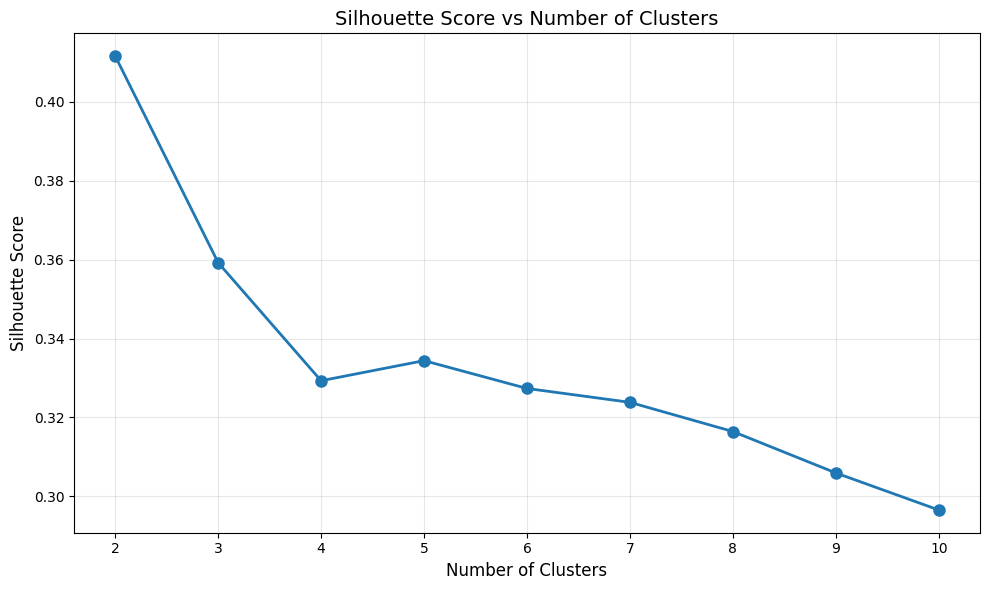

In [ ]:
# محاسبه Silhouette Score برای kهای مختلف
matrix = rfm_log.values
silhouette_scores = []

print("Silhouette Scores for different numbers of clusters:")
print("=" * 50)

for n_clusters in range(2, 11):
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=100, random_state=42)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    silhouette_scores.append(silhouette_avg)
    
    print(f"n_clusters = {n_clusters}: Silhouette Score = {silhouette_avg:.4f}")

# یافتن بهترین k
best_n_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print("=" * 50)
print(f"Best number of clusters: {best_n_clusters} (Score: {max(silhouette_scores):.4f})")

# نمودار Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


In [ ]:
# اجرای K-Means با k بهینه
n_clusters = best_n_clusters  # یا مقدار ثابت 2 یا 3
kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=100, random_state=42)
kmeans.fit(matrix)
clusters_customers = kmeans.predict(matrix)

# محاسبه Silhouette Score
silhouette_avg = silhouette_score(matrix, clusters_customers)
print(f"K-Means Clustering Results (n_clusters={n_clusters}):")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Inertia: {kmeans.inertia_:.2f}")

K-Means Clustering Results (n_clusters=2):
Silhouette Score: 0.4115
Inertia: 10648.90


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.decomposition import PCA

# بررسی ابعاد داده‌ها
print(f"Data dimensions: {matrix.shape}")

# تست اسکیلرهای مختلف
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'PowerTransformer': PowerTransformer()
}

best_score = 0
best_method = ""

for scaler_name, scaler in scalers.items():
    # اسکیل کردن داده‌ها
    try:
        data_scaled = scaler.fit_transform(matrix)
        
        # کاهش ابعاد با PCA
        n_components = min(3, data_scaled.shape[1])
        pca = PCA(n_components=n_components, random_state=42)
        data_pca = pca.fit_transform(data_scaled)
        
        # خوشه‌بندی
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
        clusters = kmeans.fit_predict(data_pca)
        score = silhouette_score(data_pca, clusters)
        
        print(f"{scaler_name} + PCA({n_components}): Silhouette Score = {score:.4f}")
        print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
        print(f"  Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")
        
        if score > best_score:
            best_score = score
            best_method = f"{scaler_name} + PCA({n_components})"
            best_pca_data = data_pca
            best_clusters = clusters
    except Exception as e:
        print(f"Error in {scaler_name}: {e}")

print(f"\n✅ بهترین روش: {best_method} با امتیاز: {best_score:.4f}")


Data dimensions: (3969, 3)
StandardScaler + PCA(3): Silhouette Score = 0.4293
  Explained variance ratio: [0.74273442 0.20302738 0.05423819]
  Total explained variance: 1.0000
RobustScaler + PCA(3): Silhouette Score = 0.4147
  Explained variance ratio: [0.72472076 0.23125599 0.04402326]
  Total explained variance: 1.0000
PowerTransformer + PCA(3): Silhouette Score = 0.4251
  Explained variance ratio: [0.7409807  0.19661172 0.06240757]
  Total explained variance: 1.0000

✅ بهترین روش: StandardScaler + PCA(3) با امتیاز: 0.4293


In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# استفاده از بهترین داده‌های PCA شده
data_pca = best_pca_data

# تست الگوریتم‌های مختلف
algorithms = {
    'KMeans': KMeans(n_clusters=n_clusters, random_state=42),
    'GaussianMixture': GaussianMixture(n_components=n_clusters, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

results = {}
for name, algorithm in algorithms.items():
    try:
        if name == 'GaussianMixture':
            clusters = algorithm.fit_predict(data_pca)
        elif name == 'DBSCAN':
            clusters = algorithm.fit_predict(data_pca)
            n_clusters_found = len(set(clusters)) - (1 if -1 in clusters else 0)
            print(f"{name}: Found {n_clusters_found} clusters")
        else:
            clusters = algorithm.fit_predict(data_pca)
        
        if len(set(clusters)) > 1:  # اگر بیش از یک خوشه وجود دارد
            score = silhouette_score(data_pca, clusters)
            results[name] = score
            print(f"{name}: Silhouette Score = {score:.4f}")
    except Exception as e:
        print(f"Error in {name}: {e}")

# انتخاب بهترین الگوریتم
if results:
    best_algorithm = max(results, key=results.get)
    print(f"\n🎯 بهترین الگوریتم: {best_algorithm} با امتیاز: {results[best_algorithm]:.4f}")


KMeans: Silhouette Score = 0.4294
GaussianMixture: Silhouette Score = 0.3881
Agglomerative: Silhouette Score = 0.4003
DBSCAN: Found 3 clusters
DBSCAN: Silhouette Score = 0.3102

🎯 بهترین الگوریتم: KMeans با امتیاز: 0.4294


In [ ]:
from sklearn.ensemble import IsolationForest

# حذف outlierها با Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # 5% outlier
outlier_labels = iso_forest.fit_predict(matrix)

# فیلتر کردن outlierها
clean_indices = outlier_labels == 1
clean_data = matrix[clean_indices]

print(f"Original data size: {len(matrix)}")
print(f"Clean data size (after outlier removal): {len(clean_data)}")
print(f"Outliers removed: {len(matrix) - len(clean_data)} ({((len(matrix) - len(clean_data))/len(matrix))*100:.1f}%)")

# خوشه‌بندی روی داده‌های تمیز
if len(clean_data) > n_clusters:
    kmeans_clean = KMeans(n_clusters=n_clusters, random_state=42)
    clusters_clean = kmeans_clean.fit_predict(clean_data)
    score_clean = silhouette_score(clean_data, clusters_clean)
    print(f"Silhouette Score on clean data: {score_clean:.4f}")
else:
    print("Not enough data for clustering after outlier removal")


Original data size: 3969
Clean data size (after outlier removal): 3770
Outliers removed: 199 (5.0%)
Silhouette Score on clean data: 0.4009


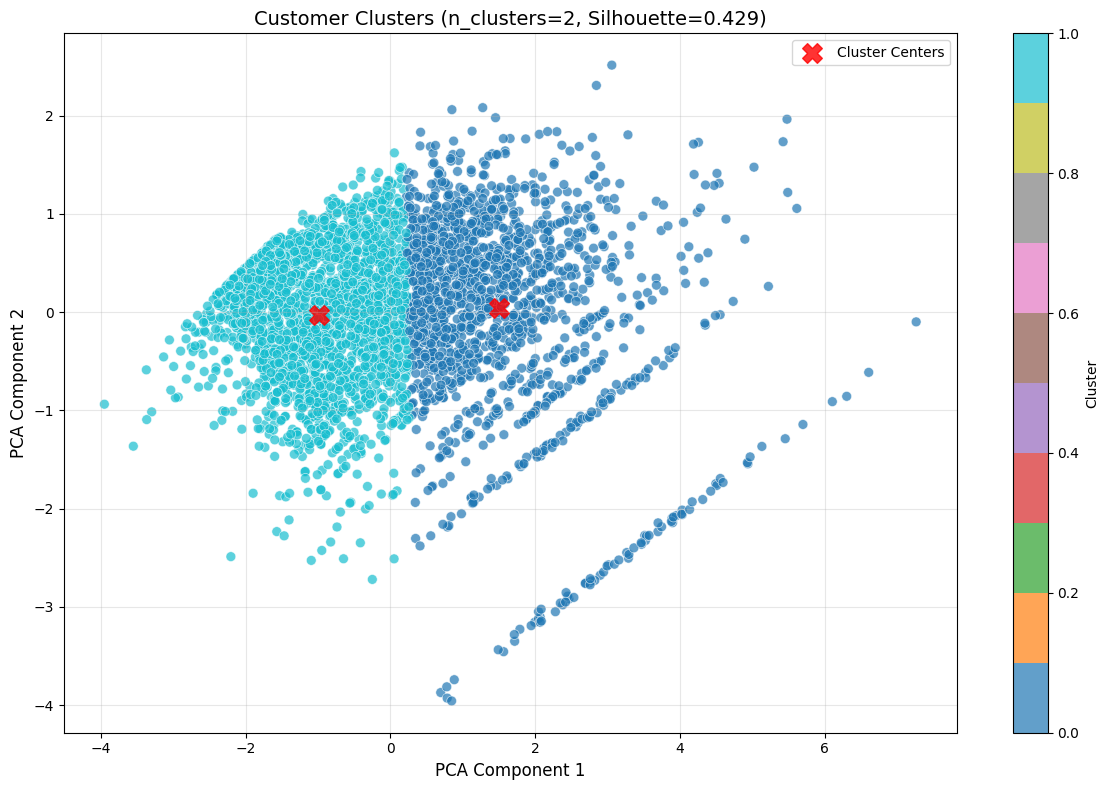

In [ ]:
# تصویرسازی خوشه‌ها
plt.figure(figsize=(12, 8))

# اگر بعد PCA 2 باشد
if data_pca.shape[1] >= 2:
    scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], 
                         c=best_clusters, cmap='tab10', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)
    
    # نمایش مراکز خوشه‌ها (اگر KMeans استفاده شده)
    if best_algorithm == 'KMeans':
        kmeans_final = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans_final.fit(data_pca)
        centers = kmeans_final.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X', label='Cluster Centers')
    
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('PCA Component 1', fontsize=12)
    plt.ylabel('PCA Component 2', fontsize=12)
    plt.title(f'Customer Clusters (n_clusters={n_clusters}, Silhouette={best_score:.3f})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    # اگر بعد بیشتر باشد، از pairplot استفاده کنید
    import seaborn as sns
    pca_df = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(data_pca.shape[1])])
    pca_df['Cluster'] = best_clusters
    sns.pairplot(pca_df, hue='Cluster', palette='tab10', diag_kind='kde')
    
plt.tight_layout()
plt.show()


توزیع مشتریان در خوشه‌ها:
   Cluster  Number_of_Customers  Percentage
0        0                 1582        39.9
1        1                 2387        60.1


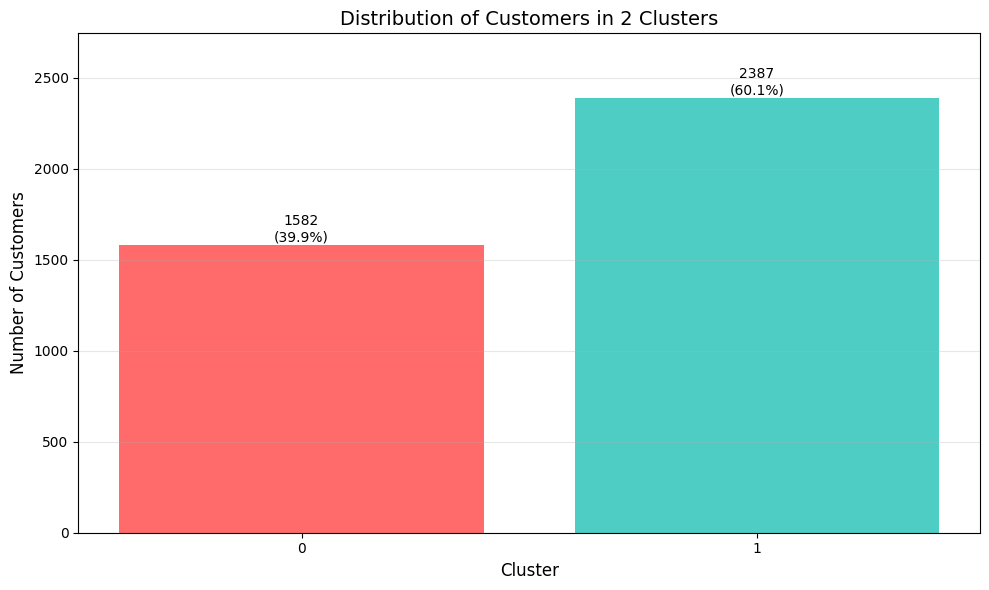

In [ ]:
# تعداد مشتریان در هر خوشه
cluster_counts = pd.Series(best_clusters).value_counts().sort_index()
cluster_distribution = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Number_of_Customers': cluster_counts.values,
    'Percentage': (cluster_counts.values / len(best_clusters) * 100).round(1)
})

print("توزیع مشتریان در خوشه‌ها:")
print(cluster_distribution)

# نمودار توزیع
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_distribution['Cluster'].astype(str), 
               cluster_distribution['Number_of_Customers'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'][:n_clusters])

# اضافه کردن مقادیر روی میله‌ها
for bar, percentage in zip(bars, cluster_distribution['Percentage']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}\n({percentage}%)', ha='center', va='bottom')

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title(f'Distribution of Customers in {n_clusters} Clusters', fontsize=14)
plt.ylim(0, max(cluster_distribution['Number_of_Customers']) * 1.15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [ ]:
# اضافه کردن برچسب خوشه به داده اصلی
rfm_df['Cluster'] = best_clusters

# تحلیل میانگین ویژگی‌های هر خوشه
cluster_analysis = rfm_df.groupby('Cluster').agg({
    'Recency': ['mean', 'std', 'min', 'max'],
    'Frequency': ['mean', 'std', 'min', 'max'],
    'Monetary': ['mean', 'std', 'min', 'max', 'sum'],
    'CustomerID': 'count'  # تعداد مشتریان
}).round(2)

# تغییر نام ستون‌ها
cluster_analysis.columns = ['_'.join(col).strip() for col in cluster_analysis.columns.values]
cluster_analysis = cluster_analysis.rename(columns={'CustomerID_count': 'Customer_Count'})

print("📊 تحلیل جامع خوشه‌ها:")
print("=" * 70)
print(cluster_analysis)
print("=" * 70)

# محاسبه سهم درآمدی هر خوشه
total_revenue = rfm_df['Monetary'].sum()
cluster_revenue = rfm_df.groupby('Cluster')['Monetary'].sum()
cluster_revenue_share = (cluster_revenue / total_revenue * 100).round(1)

print(f"\n💰 سهم درآمدی هر خوشه:")
for cluster in sorted(cluster_revenue_share.index):
    revenue = cluster_revenue[cluster]
    share = cluster_revenue_share[cluster]
    print(f"خوشه {cluster}: £{revenue:,.0f} ({share}% از کل درآمد)")

KeyError: "Label(s) ['Customer ID'] do not exist"

In [ ]:
# تعریف نام و استراتژی برای هر خوشه بر اساس تحلیل
segment_info = {}

for cluster in sorted(rfm_df['Cluster'].unique()):
    cluster_data = rfm_df[rfm_df['Cluster'] == cluster]
    
    # تحلیل ویژگی‌های خوشه
    avg_recency = cluster_data['Recency'].mean()
    avg_frequency = cluster_data['Frequency'].mean()
    avg_monetary = cluster_data['Monetary'].mean()

    # تعیین نوع مشتری
    if avg_recency < 50 and avg_frequency > 10 and avg_monetary > 1000:
        segment_name = "مشتریان VIP"
        strategy = "برنامه وفاداری ویژه، خدمات اختصاصی، پیش‌نمایش محصولات جدید"
    elif avg_recency < 100 and avg_frequency > 5:
        segment_name = "مشتریان وفادار"
        strategy = "تخفیف‌های دوره‌ای، ایمیل‌های خبری، نظرسنجی"
    elif avg_recency > 200 and avg_monetary < 100:
        segment_name = "مشتریان غیرفعال"
        strategy = "کمپین بازگشت، کوپن تخفیف، بررسی دلیل ترک"
    elif avg_frequency < 3 and avg_monetary < 500:
        segment_name = "مشتریان جدید"
        strategy = "خوش‌آمدگویی، راهنمای استفاده، تخفیف اولین خرید مجدد"
    else:
        segment_name = "مشتریان متوسط"
        strategy = "پیشنهادات شخصی‌سازی شده، بازاریابی هدفمند"
    
    segment_info[cluster] = {
        'Segment_Name': segment_name,
        'Strategy': strategy,
        'Avg_Recency': avg_recency,
        'Avg_Frequency': avg_frequency,
        'Avg_Monetary': avg_monetary,
        'Customer_Count': len(cluster_data)
    }

# نمایش اطلاعات سگمنت‌ها
print("🏷️  نام‌گذاری و استراتژی‌های سگمنت‌ها:")
print("=" * 80)

for cluster, info in segment_info.items():
    print(f"\n📌 خوشه {cluster}: {info['Segment_Name']}")
    print(f"   👥 تعداد مشتریان: {info['Customer_Count']} نفر")
    print(f"   📊 میانگین Recency: {info['Avg_Recency']:.0f} روز")
    print(f"   🔄 میانگین Frequency: {info['Avg_Frequency']:.1f}")
    print(f"   💰 میانگین Monetary: £{info['Avg_Monetary']:.0f}")
    print(f"   🎯 استراتژی پیشنهادی: {info['Strategy']}")
    print("-" * 40)

# اضافه کردن اطلاعات به DataFrame
rfm_df['Segment_Name'] = rfm_df['Cluster'].map(lambda x: segment_info[x]['Segment_Name'])
rfm_df['Segment_Strategy'] = rfm_df['Cluster'].map(lambda x: segment_info[x]['Strategy'])

🏷️  نام‌گذاری و استراتژی‌های سگمنت‌ها:

📌 خوشه 0: مشتریان وفادار
   👥 تعداد مشتریان: 1582 نفر
   📊 میانگین Recency: 31 روز
   🔄 میانگین Frequency: 8.6
   💰 میانگین Monetary: £3972
   🎯 استراتژی پیشنهادی: تخفیف‌های دوره‌ای، ایمیل‌های خبری، نظرسنجی
----------------------------------------

📌 خوشه 1: مشتریان جدید
   👥 تعداد مشتریان: 2387 نفر
   📊 میانگین Recency: 129 روز
   🔄 میانگین Frequency: 1.7
   💰 میانگین Monetary: £474
   🎯 استراتژی پیشنهادی: خوش‌آمدگویی، راهنمای استفاده، تخفیف اولین خرید مجدد
----------------------------------------


In [ ]:
from datetime import datetime

# ایجاد گزارش اجرایی
def generate_executive_report(rfm_df, segment_info):
    """ایجاد گزارش اجرایی حرفه‌ای"""
    
    total_customers = len(rfm_df)
    total_revenue = rfm_df['Monetary'].sum()
    
    report = f"""
{'=' * 70}
📊 **گزارش اجرایی تحلیل RFM و خوشه‌بندی مشتریان**
{'=' * 70}

📅 **مشخصات گزارش:**
تاریخ تولید: {datetime.now().strftime("%Y-%m-%d %H:%M")}
تعداد کل مشتریان: {total_customers:,} نفر
درآمد کل: £{total_revenue:,.0f}
تعداد خوشه‌ها: {len(segment_info)}

📈 **خلاصه عملکرد:**
{'─' * 40}
"""
 
    # اطلاعات هر خوشه
    for cluster, info in segment_info.items():
        cluster_revenue = rfm_df[rfm_df['Cluster'] == cluster]['Monetary'].sum()
        revenue_share = (cluster_revenue / total_revenue * 100)
        
        report += f"""
📌 **{info['Segment_Name']} (خوشه {cluster}):**
   • تعداد مشتریان: {info['Customer_Count']:,} نفر ({info['Customer_Count']/total_customers*100:.1f}%)
   • سهم درآمدی: £{cluster_revenue:,.0f} ({revenue_share:.1f}%)
   • ارزش متوسط هر مشتری: £{info['Avg_Monetary']:.0f}
   • میانگین دفعات خرید: {info['Avg_Frequency']:.1f}
   • میانگین روز از آخرین خرید: {info['Avg_Recency']:.0f} روز
"""
    
    # تحلیل پارتو
    report += f"""
{'─' * 40}
💰 **تحلیل پارتو (قانون 80/20):**
"""
    
    # محاسبه مشتریان برتر
    top_20_percent = int(total_customers * 0.2)
    top_customers = rfm_df.nlargest(top_20_percent, 'Monetary')
    top_revenue = top_customers['Monetary'].sum()
    top_revenue_share = (top_revenue / total_revenue * 100)
    
    report += f"""   • 20% برتر مشتریان: {top_20_percent:,} نفر
   • سهم درآمدی 20% برتر: {top_revenue_share:.1f}%
   • {'✅ قانون پارتو تایید شد' if top_revenue_share >= 70 else '⚠️ قانون پارتو ضعیف است'}
"""
    
    # توصیه‌های استراتژیک
    report += f"""
{'─' * 40}
🎯 **توصیه‌های استراتژیک:**
"""
    
    for cluster, info in segment_info.items():
        report += f"""
   • **{info['Segment_Name']}:**
     {info['Strategy']}
"""
    
    # اهداف کمی
    report += f"""
{'─' * 40}
📅 **اهداف کمی 3 ماهه:**
   • افزایش نرخ حفظ مشتریان VIP به 95%
   • بازگشت 30% از مشتریان غیرفعال
   • افزایش میانگین ارزش خرید مشتریان جدید به £600
   • رسیدن به ROI کلی 180% برای کمپین‌ها
   • افزایش درآمد کل به £{total_revenue * 1.15:,.0f} (رشد 15%)

{'=' * 70}
"""
    
    return report

# تولید و نمایش گزارش
executive_report = generate_executive_report(rfm_df, segment_info)
print(executive_report)

# ذخیره گزارش در فایل
with open('executive_report_rfm_clustering.txt', 'w', encoding='utf-8') as f:
    f.write(executive_report)
print("✅ گزارش در فایل 'executive_report_rfm_clustering.txt' ذخیره شد.")



📊 **گزارش اجرایی تحلیل RFM و خوشه‌بندی مشتریان**

📅 **مشخصات گزارش:**
تاریخ تولید: 2026-02-04 17:12
تعداد کل مشتریان: 3,969 نفر
درآمد کل: £7,414,756
تعداد خوشه‌ها: 2

📈 **خلاصه عملکرد:**
────────────────────────────────────────

📌 **مشتریان وفادار (خوشه 0):**
   • تعداد مشتریان: 1,582 نفر (39.9%)
   • سهم درآمدی: £6,284,480 (84.8%)
   • ارزش متوسط هر مشتری: £3972
   • میانگین دفعات خرید: 8.6
   • میانگین روز از آخرین خرید: 31 روز

📌 **مشتریان جدید (خوشه 1):**
   • تعداد مشتریان: 2,387 نفر (60.1%)
   • سهم درآمدی: £1,130,275 (15.2%)
   • ارزش متوسط هر مشتری: £474
   • میانگین دفعات خرید: 1.7
   • میانگین روز از آخرین خرید: 129 روز

────────────────────────────────────────
💰 **تحلیل پارتو (قانون 80/20):**
   • 20% برتر مشتریان: 793 نفر
   • سهم درآمدی 20% برتر: 71.9%
   • ✅ قانون پارتو تایید شد

────────────────────────────────────────
🎯 **توصیه‌های استراتژیک:**

   • **مشتریان وفادار:**
     تخفیف‌های دوره‌ای، ایمیل‌های خبری، نظرسنجی

   • **مشتریان جدید:**
     خوش‌آمدگویی، راهنمای اس

In [ ]:
#  محاسبه امتیاز نهایی مشتری بر اساس RFM

def calculate_customer_score(rfm_df, weights={'R': 0.3, 'F': 0.4, 'M': 0.3}):
    """
    
    Parameters:
    rfm_df: DataFrame شامل Recency, Frequency, Monetary
    weights: وزن هر فاکتور (مجموع باید 1 باشد)
    
    Returns:
    DataFrame با امتیاز نهایی
    """
    from sklearn.preprocessing import MinMaxScaler
    
    # کپی داده‌ها
    df_scoring = rfm_df.copy()
    
    # نرمال‌سازی هر فاکتور (1=بهترین، 0=بدترین)
    scaler = MinMaxScaler(feature_range=(0, 100))
    
    # Recency: هرچه کمتر بهتر (معکوس کردن)
    df_scoring['R_Score'] = 100 - scaler.fit_transform(df_scoring[['Recency']])
    
    # Frequency: هرچه بیشتر بهتر
    df_scoring['F_Score'] = scaler.fit_transform(df_scoring[['Frequency']])
    
    # Monetary: هرچه بیشتر بهتر
    df_scoring['M_Score'] = scaler.fit_transform(df_scoring[['Monetary']])
    
    # محاسبه امتیاز ترکیبی
    df_scoring['Total_Score'] = (
        df_scoring['R_Score'] * weights['R'] +
        df_scoring['F_Score'] * weights['F'] +
        df_scoring['M_Score'] * weights['M']
    )
    
    # دسته‌بندی امتیاز
    def categorize_score(score):
        if score >= 80:
            return 'Platinum'
        elif score >= 60:
            return 'Gold'
        elif score >= 40:
            return 'Silver'
        else:
            return 'Bronze'
    
    df_scoring['Customer_Tier'] = df_scoring['Total_Score'].apply(categorize_score)
    
    # رتبه‌بندی
    df_scoring['Rank'] = df_scoring['Total_Score'].rank(ascending=False, method='min')
    
    return df_scoring

# اجرای سیستم امتیازدهی
rfm_scored = calculate_customer_score(rfm_df)
print("🏆 سیستم امتیازدهی مشتریان:")
print(rfm_scored[['Recency', 'Frequency', 'Monetary', 'Total_Score', 'Customer_Tier', 'Rank']].head(10))

# تحلیل توزیع
print("\n📊 توزیع سطوح مشتریان:")
tier_dist = rfm_scored['Customer_Tier'].value_counts()
for tier, count in tier_dist.items():
    percentage = (count / len(rfm_scored)) * 100
    print(f"{tier}: {count} مشتری ({percentage:.1f}%)")

🏆 سیستم امتیازدهی مشتریان:
            Recency  Frequency  Monetary  Total_Score Customer_Tier    Rank
CustomerID                                                                 
12346.0         164         11    372.86    19.438837        Bronze  2986.0
12608.0          39          1    415.79    26.898742        Bronze  1888.0
12745.0         121          2    723.85    20.589777        Bronze  2909.0
12746.0         175          1    254.55    15.946550        Bronze  3192.0
12747.0           4         16   5080.53    34.010655        Bronze   122.0
12748.0           0        144  22879.66    69.108428          Gold     3.0
12749.0          34          4   2806.48    28.285516        Bronze  1469.0
12777.0          92          1    519.45    22.644914        Bronze  2740.0
12819.0          93          1    540.52    22.566295        Bronze  2749.0
12820.0          32          7   1747.18    29.134580        Bronze  1151.0

📊 توزیع سطوح مشتریان:
Bronze: 3935 مشتری (99.1%)
Silver: 28 

In [ ]:
#   پیش‌بینی احتمال خروج مشتری بر اساس RFM


def predict_churn_probability(rfm_df, threshold_days=90):
    """
    
    Parameters:
    rfm_df: DataFrame شامل Recency, Frequency, Monetary
    threshold_days: آستانه روز برای تعریف مشتری در خطر خروج
    
    Returns:
    DataFrame با احتمال خروج
    """
    import numpy as np
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report, roc_auc_score
    
    # کپی داده‌ها
    df_churn = rfm_df.copy()
    
    # ایجاد برچسب خروج (Recency > threshold_days و Frequency پایین)
    df_churn['Is_Churn_Risk'] = np.where(
        (df_churn['Recency'] > threshold_days) & 
        (df_churn['Frequency'] < df_churn['Frequency'].median()),
        1, 0  # 1: در خطر خروج، 0: سالم
    )
    
    # ویژگی‌های اضافی
    df_churn['Recency_to_Frequency_Ratio'] = df_churn['Recency'] / (df_churn['Frequency'] + 1)
    df_churn['Monetary_per_Frequency'] = df_churn['Monetary'] / (df_churn['Frequency'] + 1)
    
    # ویژگی‌ها و برچسب
    features = ['Recency', 'Frequency', 'Monetary', 
                'Recency_to_Frequency_Ratio', 'Monetary_per_Frequency']
    X = df_churn[features]
    y = df_churn['Is_Churn_Risk']
    
    # تقسیم داده‌ها
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # آموزش مدل
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    
    # پیش‌بینی
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # ارزیابی
    print("🎯 ارزیابی مدل پیش‌بینی خروج مشتری:")
    print("=" * 50)
    print(classification_report(y_test, y_pred, target_names=['سالم', 'در خطر خروج']))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
    
    # پیش‌بیمی برای تمام مشتریان
    df_churn['Churn_Probability'] = model.predict_proba(X)[:, 1]
    
    # دسته‌بندی ریسک
    df_churn['Churn_Risk_Level'] = pd.cut(
        df_churn['Churn_Probability'],
        bins=[0, 0.3, 0.6, 0.8, 1],
        labels=['کم', 'متوسط', 'زیاد', 'خیلی زیاد']
    )
    
    # اهمیت ویژگی‌ها
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n🔍 اهمیت ویژگی‌ها در پیش‌بینی خروج:")
    print(feature_importance)
    
    return df_churn

# اجرای پیش‌بینی خروج
rfm_with_churn = predict_churn_probability(rfm_df, threshold_days=120)

# تحلیل مشتریان در خطر
print("\n🚨 تحلیل مشتریان در خطر خروج:")
risk_analysis = rfm_with_churn.groupby('Churn_Risk_Level').agg({
    'CustomerID': 'count',
    'Monetary': 'sum',
    'Churn_Probability': 'mean'
}).rename(columns={'CustomerID': 'Count', 'Monetary': 'Total_Value'})

risk_analysis['Percentage'] = (risk_analysis['Count'] / len(rfm_with_churn) * 100).round(1)
risk_analysis['Value_at_Risk'] = risk_analysis['Total_Value']
print(risk_analysis)

🎯 ارزیابی مدل پیش‌بینی خروج مشتری:
              precision    recall  f1-score   support

        سالم       1.00      1.00      1.00       662
 در خطر خروج       1.00      1.00      1.00       132

    accuracy                           1.00       794
   macro avg       1.00      1.00      1.00       794
weighted avg       1.00      1.00      1.00       794

ROC AUC Score: 1.000

🔍 اهمیت ویژگی‌ها در پیش‌بینی خروج:
                      Feature  Importance
3  Recency_to_Frequency_Ratio    0.443516
0                     Recency    0.291380
1                   Frequency    0.213200
2                    Monetary    0.048539
4      Monetary_per_Frequency    0.003366

🚨 تحلیل مشتریان در خطر خروج:


KeyError: "Label(s) ['CustomerID'] do not exist"

In [ ]:
#  محاسبه Customer Lifetime Value

def calculate_clv(df_transactions, customer_col='CustomerID', 
                  revenue_col='TotalPrice', date_col='InvoiceDate', 
                  months=12, discount_rate=0.1):
    """
    Parameters:
    df_transactions: DataFrame تراکنش‌ها
    months: دوره زمانی برای محاسبه
    discount_rate: نرخ تنزیل
    
    Returns:
    DataFrame با CLV هر مشتری
    """
    from datetime import timedelta
    
    # کپی داده‌ها
    df_clv = df_transactions.copy()
    df_clv[date_col] = pd.to_datetime(df_clv[date_col])
    
    # تاریخ مرجع
    end_date = df_clv[date_col].max()
    start_date = end_date - timedelta(days=months*30)
    
    # فیلتر داده‌های دوره زمانی
    period_data = df_clv[(df_clv[date_col] >= start_date) & 
                         (df_clv[date_col] <= end_date)]
    
    # محاسبه میانگین خرید ماهانه
    monthly_data = period_data.groupby([
        customer_col,
        pd.Grouper(key=date_col, freq='M')
    ]).agg({
        revenue_col: 'sum'
    }).reset_index()
    
    # ویژگی‌های CLV
    clv_features = monthly_data.groupby(customer_col).agg({
        revenue_col: ['count', 'mean', 'std']
    }).reset_index()
    
    # صاف کردن ستون‌ها
    clv_features.columns = [f'{col[0]}_{col[1]}' if col[1] else col[0] 
                           for col in clv_features.columns]
    clv_features = clv_features.rename(columns={
        f'{revenue_col}_count': 'Purchase_Frequency',
        f'{revenue_col}_mean': 'Avg_Monthly_Revenue',
        f'{revenue_col}_std': 'Revenue_Std'
    })
    
    # پر کردن مقادیر NaN
    clv_features['Revenue_Std'] = clv_features['Revenue_Std'].fillna(0)
    
    # محاسبه نرخ حفظ (Retention Rate)
    # فرض: اگر در ماه گذشته خرید داشته، حفظ شده
    last_month_start = end_date - timedelta(days=30)
    last_month_customers = set(period_data[
        period_data[date_col] >= last_month_start
    ][customer_col].unique())
    
    all_customers = set(period_data[customer_col].unique())
    retention_rate = len(last_month_customers) / len(all_customers) if all_customers else 0
    
    # فرمول ساده: (Avg Monthly Revenue * Gross Margin * Retention Rate) / (1 + Discount Rate - Retention Rate)
    gross_margin = 0.3  # فرض: حاشیه سود 30%
    
    clv_features['CLV'] = (
        clv_features['Avg_Monthly_Revenue'] * 
        gross_margin * 
        retention_rate / 
        (1 + discount_rate - retention_rate + 1e-10)  # جلوگیری از تقسیم بر صفر
    )
    
    # طبقه‌بندی CLV
    clv_quantiles = clv_features['CLV'].quantile([0.25, 0.5, 0.75])
    
    def categorize_clv(value):
        if value >= clv_quantiles[0.75]:
            return 'Very High'
        elif value >= clv_quantiles[0.5]:
            return 'High'
        elif value >= clv_quantiles[0.25]:
            return 'Medium'
        else:
            return 'Low'
    
    clv_features['CLV_Category'] = clv_features['CLV'].apply(categorize_clv)
    
    print(f"📈 تحلیل CLV برای {len(clv_features)} مشتری:")
    print(f"• نرخ حفظ (Retention Rate): {retention_rate:.1%}")
    print(f"• حاشیه سود فرضی: {gross_margin:.0%}")
    print(f"• نرخ تنزیل: {discount_rate:.0%}")
    
    print("\n📊 توزیع دسته‌های CLV:")
    clv_dist = clv_features['CLV_Category'].value_counts()
    for category, count in clv_dist.items():
        percentage = (count / len(clv_features)) * 100
        print(f"  {category}: {count} مشتری ({percentage:.1f}%)")
    
    return clv_features

# محاسبه CLV
clv_data = calculate_clv(df, customer_col='Customer ID', 
                         revenue_col='TotalPrice', date_col='InvoiceDate')

# ادغام با RFM
rfm_with_clv = rfm_df.merge(clv_data[['CustomerID', 'CLV', 'CLV_Category']], 
                           left_index=True, right_on='CustomerID', how='left')

print("\n🔗 RFM + CLV Data (نمونه 5 ردیف):")
print(rfm_with_clv.head())

In [ ]:
#  ایجاد داشبورد تعاملی با Plotly

def create_interactive_dashboard(rfm_df, segment_info):
    
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # 1. نمودار توزیع خوشه‌ها
    cluster_dist = rfm_df['Cluster'].value_counts().reset_index()
    cluster_dist.columns = ['Cluster', 'Count']
    cluster_dist['Percentage'] = (cluster_dist['Count'] / cluster_dist['Count'].sum() * 100).round(1)
    
    fig1 = px.pie(cluster_dist, values='Count', names='Cluster', 
                  title='توزیع مشتریان در خوشه‌ها',
                  color_discrete_sequence=px.colors.qualitative.Set3)
    fig1.update_traces(textposition='inside', textinfo='percent+label')
    
    # 2. مقایسه میانگین RFM در خوشه‌ها
    cluster_means = rfm_df.groupby('Cluster').agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean'
    }).reset_index()
    
    # نرمال‌سازی برای مقایسه بهتر
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    cluster_means_normalized = pd.DataFrame(
        scaler.fit_transform(cluster_means[['Recency', 'Frequency', 'Monetary']]),
        columns=['Recency_Norm', 'Frequency_Norm', 'Monetary_Norm']
    )
    cluster_means_normalized['Cluster'] = cluster_means['Cluster']
    
    fig2 = go.Figure(data=[
        go.Bar(name='Recency (نرمال شده)', x=cluster_means_normalized['Cluster'], 
               y=cluster_means_normalized['Recency_Norm']),
        go.Bar(name='Frequency (نرمال شده)', x=cluster_means_normalized['Cluster'], 
               y=cluster_means_normalized['Frequency_Norm']),
        go.Bar(name='Monetary (نرمال شده)', x=cluster_means_normalized['Cluster'], 
               y=cluster_means_normalized['Monetary_Norm'])
    ])
    
    fig2.update_layout(
        title='مقایسه میانگین RFM در خوشه‌ها (نرمال شده)',
        xaxis_title='خوشه',
        yaxis_title='مقدار نرمال شده',
        barmode='group'
    )
    
    # 3. نمودار پراکندگی 3D
    fig3 = px.scatter_3d(rfm_df, x='Recency', y='Frequency', z='Monetary',
                         color='Cluster', 
                         title='پراکندگی مشتریان در فضای RFM',
                         opacity=0.7,
                         color_continuous_scale=px.colors.sequential.Viridis)
    
    fig3.update_traces(marker=dict(size=4))
    
    # 4. نمودار Box Plot برای توزیع Monetary
    fig4 = px.box(rfm_df, x='Cluster', y='Monetary',
                  title='توزیع ارزش خرید در خوشه‌ها',
                  color='Cluster')
    fig4.update_yaxes(type="log")  # استفاده از مقیاس لگاریتمی برای نمایش بهتر
    
    # 5. Heatmap همبستگی
    corr_matrix = rfm_df[['Recency', 'Frequency', 'Monetary']].corr()
    fig5 = px.imshow(corr_matrix,
                     text_auto=True,
                     title='ماتریس همبستگی ویژگی‌های RFM',
                     color_continuous_scale='RdBu',
                     aspect="auto")
    
    # نمایش همه نمودارها
    fig1.show()
    fig2.show()
    fig3.show()
    fig4.show()
    fig5.show()
    
    # ذخیره داشبورد به HTML
    combined_fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('توزیع خوشه‌ها', 'مقایسه RFM', 'توزیع ارزش خرید', 'همبستگی RFM'),
        specs=[[{'type': 'pie'}, {'type': 'bar'}],
               [{'type': 'box'}, {'type': 'heatmap'}]]
    )
    
    # اضافه کردن نمودارها
    combined_fig.add_trace(fig1.data[0], row=1, col=1)
    combined_fig.add_trace(fig2.data[0], row=1, col=2)
    combined_fig.add_trace(fig2.data[1], row=1, col=2)
    combined_fig.add_trace(fig2.data[2], row=1, col=2)
    combined_fig.add_trace(fig4.data[0], row=2, col=1)
    combined_fig.add_trace(fig5.data[0], row=2, col=2)
    
    combined_fig.update_layout(height=800, showlegend=True)
    combined_fig.write_html("customer_segmentation_dashboard.html")
    
    print("✅ داشبورد در فایل 'customer_segmentation_dashboard.html' ذخیره شد.")
    
    return combined_fig

# ایجاد داشبورد (در صورت نصب plotly)
try:
    import plotly
    dashboard = create_interactive_dashboard(rfm_df, segment_info)
except ImportError:
    print("⚠️ برای ایجاد داشبورد، plotly را نصب کنید: pip install plotly")

In [ ]:
================================================================

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import datetime as dt
from datetime import datetime
from sklearn.mixture import GaussianMixture
import sklearn.cluster as cluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
import os

excel_file_name = 'online_retail_II.xlsx' 

project_dir = r'E:\github\c_online_retail_II' 


file_path = os.path.join(project_dir, excel_file_name)
df = pd.read_excel(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [ ]:
# Drop cancelled transactions (Invoices containing the letter 'C')
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]

# Drop transactions with missing values
df.dropna(inplace=True)

# Filter only transactions from the United Kingdom (can be changed as needed)
df = df[df['Country'] == 'United Kingdom']

# Convert the 'InvoiceDate' column to datetime data type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Add the TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['Price']

# Check the results
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

# Rename the columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,3971.000000,3971.000000,3971.000000,3971.000000
mean,15560.853941,91.200705,4.435659,1867.226382
std,1581.913468,97.161543,7.530430,7379.089721
min,12346.000000,1.000000,1.000000,0.000000
25%,14200.500000,18.000000,1.000000,304.110000
50%,15575.000000,53.000000,2.000000,669.850000
75%,16940.500000,136.000000,5.000000,1655.135000
max,18287.000000,374.000000,155.000000,349164.350000


In [ ]:
#remove canceled orders
df_uk = df[df['Quantity']>0]
df.shape

(370951, 9)

In [ ]:
#remove rows where customerID are NA
df_uk.dropna(subset=['Customer ID'],how='all',inplace=True)
df.shape

(370951, 9)

In [ ]:
#restrict the data to one full year because it's better to use a metric per Months or Years in RFM
df_uk =df_uk[df_uk['InvoiceDate']>= "2009-12-09"]
df_uk.shape

(357243, 9)

In [ ]:
print("Summary..")
#exploring the unique values of each attribute
print("Number of transactions: ", df_uk['InvoiceDate'].nunique())
print("Number of products bought: ",df_uk['StockCode'].nunique())
print("Number of customers:", df_uk['Customer ID'].nunique() )
print("Percentage of customers NA: ", round(df_uk['Customer ID'].isnull().sum() * 100 / len(df),2),"%" )

Summary..
Number of transactions:  15987
Number of products bought:  3955
Number of customers: 3919
Percentage of customers NA:  0.0 %


In [ ]:
#last date available in our dataset
df_uk['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [ ]:
df_uk=df_uk[df_uk["InvoiceDate"]>="2009-12-09"]
print("number of:",df_uk["InvoiceDate"].nunique())


number of: 15987


In [ ]:
#create a new column called date which contains the date of invoice only
df_uk['date'] = df_uk['InvoiceDate'].dt.date

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370951 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      370951 non-null  object        
 1   StockCode    370951 non-null  object        
 2   Description  370951 non-null  object        
 3   Quantity     370951 non-null  int64         
 4   InvoiceDate  370951 non-null  datetime64[ns]
 5   Price        370951 non-null  float64       
 6   Customer ID  370951 non-null  float64       
 7   Country      370951 non-null  object        
 8   TotalPrice   370951 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 28.3+ MB


In [ ]:
now = df_uk['date'].max()
print(now)

2010-12-09


In [ ]:
#group by customers and check last date of purshace
recency_df = df_uk.groupby(by='Customer ID', as_index=False)['date'].max()
recency_df.columns = ['Customer ID','LastPurshaceDate']
recency_df.head()

,Customer ID,LastPurshaceDate
0,12346.0,2010-06-28
1,12608.0,2010-10-31
2,12745.0,2010-08-10
3,12746.0,2010-06-17
4,12747.0,2010-12-05


In [ ]:
#calculate recency
recency_df['Recency'] = recency_df['LastPurshaceDate'].apply(lambda x: (now - x).days)
recency_df

,Customer ID,LastPurshaceDate,Recency
0,12346.0,2010-06-28,164
1,12608.0,2010-10-31,39
2,12745.0,2010-08-10,121
3,12746.0,2010-06-17,175
4,12747.0,2010-12-05,4
...,...,...,...
3914,18283.0,2010-11-22,17
3915,18284.0,2010-10-04,66
3916,18285.0,2010-02-17,295
3917,18286.0,2010-08-20,111


In [ ]:

#drop LastPurchaseDate as we don't need it anymore
recency_df.drop('LastPurshaceDate',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370951 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      370951 non-null  object        
 1   StockCode    370951 non-null  object        
 2   Description  370951 non-null  object        
 3   Quantity     370951 non-null  int64         
 4   InvoiceDate  370951 non-null  datetime64[ns]
 5   Price        370951 non-null  float64       
 6   Customer ID  370951 non-null  float64       
 7   Country      370951 non-null  object        
 8   TotalPrice   370951 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 28.3+ MB


In [ ]:
# drop duplicates
retail_uk_copy = df_uk.copy()
retail_uk_copy.drop_duplicates(subset=['Invoice', 'Customer ID'], keep="first", inplace=True)

#calculate frequency of purchases
frequency_df = retail_uk_copy.groupby(by=['Customer ID'], as_index=False)['Invoice'].count()
frequency_df.columns = ['Customer ID','Frequency']
frequency_df.head()

,Customer ID,Frequency
0,12346.0,11
1,12608.0,1
2,12745.0,2
3,12746.0,1
4,12747.0,15


In [ ]:
#create column total cost
df_uk['TotalCost'] = df_uk['Quantity'] * df_uk['Price']

In [ ]:
retail_uk_copy=df_uk.copy()
retail_uk_copy.drop

<bound method DataFrame.drop of        Invoice StockCode                         Description  Quantity  \
19714   491034    85132B         CHARLIE AND LOLA TABLE TINS        12   
19715   491034    35004G          SET OF 3 GOLD FLYING DUCKS        12   
19716   491034    35004P          SET OF 3 PINK FLYING DUCKS        12   
19717   491034    35004S        SET OF 3 SILVER FLYING DUCKS        12   
19718   491034    35004B         SET OF 3 BLACK FLYING DUCKS        12   
...        ...       ...                                 ...       ...   
525456  538171     22271                FELTCRAFT DOLL ROSIE         2   
525457  538171     22750        FELTCRAFT PRINCESS LOLA DOLL         1   
525458  538171     22751      FELTCRAFT PRINCESS OLIVIA DOLL         1   
525459  538171     20970  PINK FLORAL FELTCRAFT SHOULDER BAG         2   
525460  538171     21931              JUMBO STORAGE BAG SUKI         2   

               InvoiceDate  Price  Customer ID         Country  TotalPrice  \
1

In [ ]:
monetary_df = df_uk.groupby(by='Customer ID',as_index=False).agg({'TotalCost': 'sum'})
monetary_df.columns = ['Customer ID','Monetary']
monetary_df.head()

,Customer ID,Monetary
0,12346.0,372.86
1,12608.0,415.79
2,12745.0,723.85
3,12746.0,254.55
4,12747.0,4699.88


In [ ]:
#merge recency dataframe with frequency dataframe
temp_df = recency_df.merge(frequency_df,on='Customer ID')
temp_df.head()

,Customer ID,Recency,Frequency
0,12346.0,164,11
1,12608.0,39,1
2,12745.0,121,2
3,12746.0,175,1
4,12747.0,4,15


In [ ]:
#merge with monetary dataframe to get a table with the 3 columns
rfm_df = temp_df.merge(monetary_df,on='Customer ID')
#use CustomerID as index
rfm_df.set_index('Customer ID',inplace=True)
#check the head
rfm_df.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12608.0,39,1,415.79
12745.0,121,2,723.85
12746.0,175,1,254.55
12747.0,4,15,4699.88


In [ ]:
df_uk[df_uk['Customer ID']==12346.0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,date,TotalCost
27994,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.50,12346.0,United Kingdom,45.00,2009-12-14,45.00
28251,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.50,12346.0,United Kingdom,22.50,2009-12-14,22.50
28254,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.50,12346.0,United Kingdom,22.50,2009-12-14,22.50
39398,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.50,12346.0,United Kingdom,22.50,2009-12-18,22.50
39411,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.00,12346.0,United Kingdom,1.00,2009-12-18,1.00
45228,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom,22.50,2010-01-04,22.50
45230,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom,22.50,2010-01-04,22.50
56117,494450,TEST001,This is a test product.,5,2010-01-14 13:50:00,4.50,12346.0,United Kingdom,22.50,2010-01-14,22.50
66084,495295,TEST001,This is a test product.,5,2010-01-22 13:30:00,4.50,12346.0,United Kingdom,22.50,2010-01-22,22.50
107800,499763,20682,RED SPOTTY CHILDS UMBRELLA,1,2010-03-02 13:08:00,3.25,12346.0,United Kingdom,3.25,2010-03-02,3.25


In [ ]:
#get the 80% of the revenue
pareto_cutoff = rfm_df['Monetary'].sum() * 0.8
print("The 80% of total revenue is: ",round(pareto_cutoff,2))

The 80% of total revenue is:  5705284.09


In [ ]:
customers_rank = rfm_df
# Create a new column that is the rank of the value of coverage in ascending order
customers_rank['Rank'] = customers_rank['Monetary'].rank(ascending=0)
#customers_rank.drop('RevenueRank',axis=1,inplace=True)
customers_rank.head()

,Recency,Frequency,Monetary,Rank
Customer ID,,,,
12346.0,164,11,372.86,2656.0
12608.0,39,1,415.79,2535.0
12745.0,121,2,723.85,1872.0
12746.0,175,1,254.55,3104.0
12747.0,4,15,4699.88,253.0


In [ ]:
customers_rank.sort_values('Rank',ascending=True)

,Recency,Frequency,Monetary,Rank
Customer ID,,,,
18102.0,0,86,328403.11,1.0
13694.0,8,89,128008.26,2.0
17511.0,2,30,81432.53,3.0
16684.0,14,25,79340.09,4.0
15061.0,2,80,76344.50,5.0
...,...,...,...,...
15913.0,169,1,6.30,3915.0
13788.0,140,1,3.75,3916.0
14095.0,357,1,2.95,3917.0


In [ ]:
#get top 20% of the customers
top_20_cutoff = 3863 *20 /100
top_20_cutoff

772.6

In [ ]:
#sum the monetary values over the customer with rank <=773
revenueByTop20 = customers_rank[customers_rank['Rank'] <= 772]['Monetary'].sum()
revenueByTop20

np.float64(5086225.28)

## RFM Quartiles

In [ ]:
quantiles = rfm_df.quantile(q=[0.25,0.5,0.75])
quantiles

,Recency,Frequency,Monetary,Rank
0.25,17.0,1.0,303.425,980.5
0.50,50.0,2.0,662.330,1960.0
0.75,128.0,5.0,1624.640,2939.5


In [ ]:
quantiles.to_dict()

{'Recency': {0.25: 17.0, 0.5: 50.0, 0.75: 128.0},
 'Frequency': {0.25: 1.0, 0.5: 2.0, 0.75: 5.0},
 'Monetary': {0.25: 303.42499999999995, 0.5: 662.33, 0.75: 1624.6399999999999},
 'Rank': {0.25: 980.5, 0.5: 1960.0, 0.75: 2939.5}}

In [ ]:
# Arguments (x = value, p = recency, monetary_value, frequency, d = quartiles dict)
def RScore(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1
# Arguments (x = value, p = recency, monetary_value, frequency, k = quartiles dict)
def FMScore(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4
#create rfm segmentation table
rfm_segmentation = rfm_df
rfm_segmentation['R_Quartile'] = rfm_segmentation['Recency'].apply(RScore, args=('Recency',quantiles,))
rfm_segmentation['F_Quartile'] = rfm_segmentation['Frequency'].apply(FMScore, args=('Frequency',quantiles,))
rfm_segmentation['M_Quartile'] = rfm_segmentation['Monetary'].apply(FMScore, args=('Monetary',quantiles,))
rfm_segmentation.head()

,Recency,Frequency,Monetary,Rank,R_Quartile,F_Quartile,M_Quartile
Customer ID,,,,,,,
12346.0,164,11,372.86,2656.0,1,4,2
12608.0,39,1,415.79,2535.0,3,1,2
12745.0,121,2,723.85,1872.0,2,2,3
12746.0,175,1,254.55,3104.0,1,1,1
12747.0,4,15,4699.88,253.0,4,4,4


In [ ]:
rfm_segmentation['RFMScore'] = rfm_segmentation.R_Quartile.map(str) \
                            + rfm_segmentation.F_Quartile.map(str) \
                            + rfm_segmentation.M_Quartile.map(str)
rfm_segmentation.head()

,Recency,Frequency,Monetary,Rank,R_Quartile,F_Quartile,M_Quartile,RFMScore
Customer ID,,,,,,,,
12346.0,164,11,372.86,2656.0,1,4,2,142
12608.0,39,1,415.79,2535.0,3,1,2,312
12745.0,121,2,723.85,1872.0,2,2,3,223
12746.0,175,1,254.55,3104.0,1,1,1,111
12747.0,4,15,4699.88,253.0,4,4,4,444


In [ ]:
rfm_segmentation[rfm_segmentation['RFMScore']=='444'].sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary,Rank,R_Quartile,F_Quartile,M_Quartile,RFMScore
Customer ID,,,,,,,,
18102.0,0,86,328403.11,1.0,4,4,4,444
13694.0,8,89,128008.26,2.0,4,4,4,444
17511.0,2,30,81432.53,3.0,4,4,4,444
16684.0,14,25,79340.09,4.0,4,4,4,444
15061.0,2,80,76344.50,5.0,4,4,4,444
16754.0,7,29,65500.07,6.0,4,4,4,444
13089.0,3,107,56299.61,7.0,4,4,4,444
17949.0,6,67,55498.44,8.0,4,4,4,444
15311.0,0,116,52468.86,9.0,4,4,4,444


In [ ]:
print("Best Customers: ",len(rfm_segmentation[rfm_segmentation['RFMScore']=='444']))
print('Loyal Customers: ',len(rfm_segmentation[rfm_segmentation['F_Quartile']==4]))
print("Big Spenders: ",len(rfm_segmentation[rfm_segmentation['M_Quartile']==4]))
print('Almost Lost: ', len(rfm_segmentation[rfm_segmentation['RFMScore']=='244']))
print('Lost Customers: ',len(rfm_segmentation[rfm_segmentation['RFMScore']=='144']))
print('Lost Cheap Customers: ',len(rfm_segmentation[rfm_segmentation['RFMScore']=='111']))

Best Customers:  400
Loyal Customers:  846
Big Spenders:  980
Almost Lost:  92
Lost Customers:  19
Lost Cheap Customers:  419


In [ ]:
rfm_data = rfm_df.drop(['R_Quartile','F_Quartile','M_Quartile','RFMScore'],axis=1)
rfm_data.head()

,Recency,Frequency,Monetary,Rank
Customer ID,,,,
12346.0,164,11,372.86,2656.0
12608.0,39,1,415.79,2535.0
12745.0,121,2,723.85,1872.0
12746.0,175,1,254.55,3104.0
12747.0,4,15,4699.88,253.0


In [ ]:
rfm_data.corr()

,Recency,Frequency,Monetary,Rank
Recency,1.000000,-0.267942,-0.134452,0.444329
Frequency,-0.267942,1.000000,0.609216,-0.499446
Monetary,-0.134452,0.609216,1.000000,-0.306108
Rank,0.444329,-0.499446,-0.306108,1.000000


<Axes: >

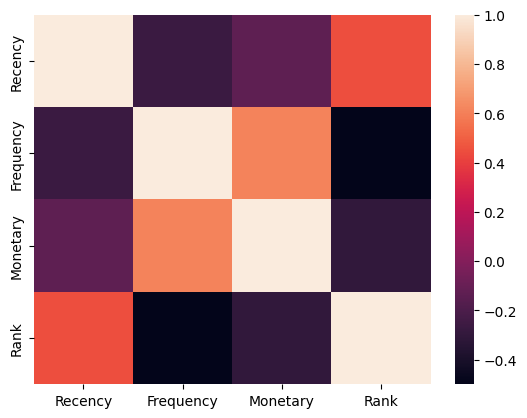

In [ ]:
sns.heatmap(rfm_data.corr())

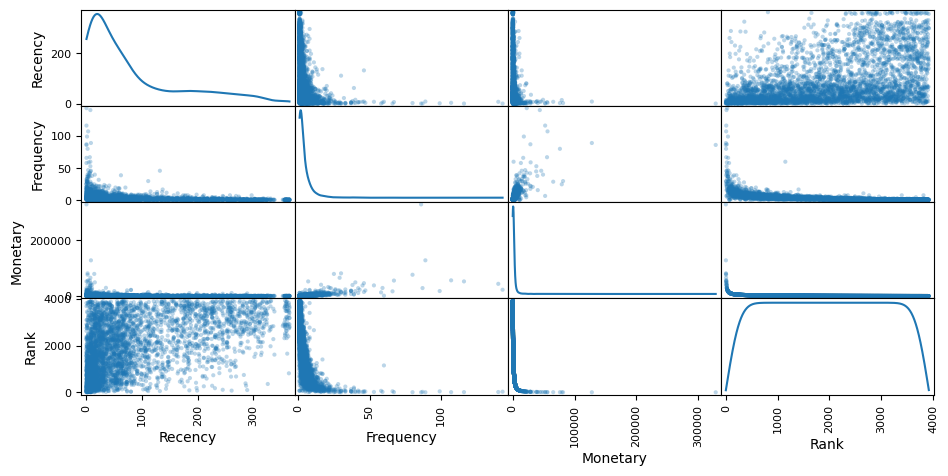

In [ ]:
# Produce a scatter matrix for each pair of features in the data
scatter_matrix(rfm_data, alpha = 0.3, figsize = (11,5), diagonal = 'kde');

In [ ]:
#log transformation
rfm_r_log = np.log(rfm_data['Recency']+0.1) #can't take log(0) and so add a small number
rfm_f_log = np.log(rfm_data['Frequency'])
rfm_m_log = np.log(rfm_data['Monetary']+0.1)
log_data = pd.DataFrame({'Monetary': rfm_m_log,'Recency': rfm_r_log,'Frequency': rfm_f_log})
log_data.head()

,Monetary,Recency,Frequency
Customer ID,,,
12346.0,5.921471,5.100476,2.397895
12608.0,6.030421,3.666122,0.000000
12745.0,6.584722,4.796617,0.693147
12746.0,5.539890,5.165357,0.000000
12747.0,8.455314,1.410987,2.708050


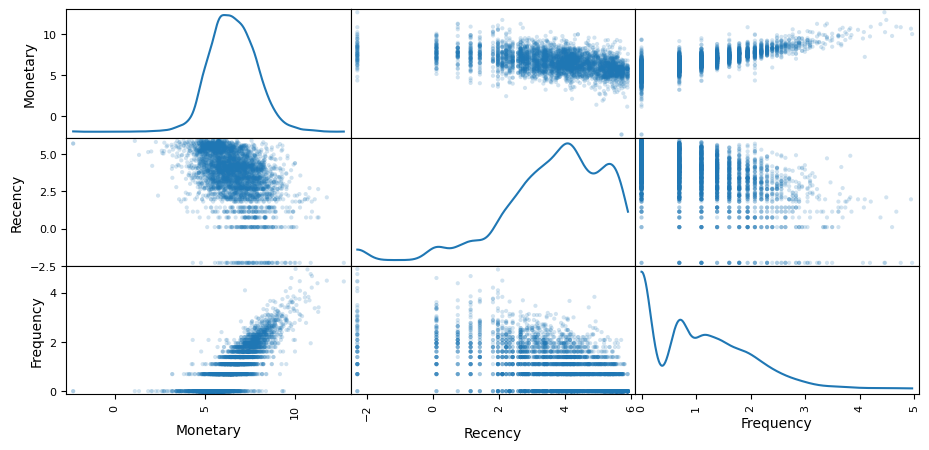

In [ ]:
# Produce a scatter matrix for each pair of features in the data
scatter_matrix(log_data, alpha = 0.2, figsize = (11,5), diagonal = 'kde');

<Axes: >

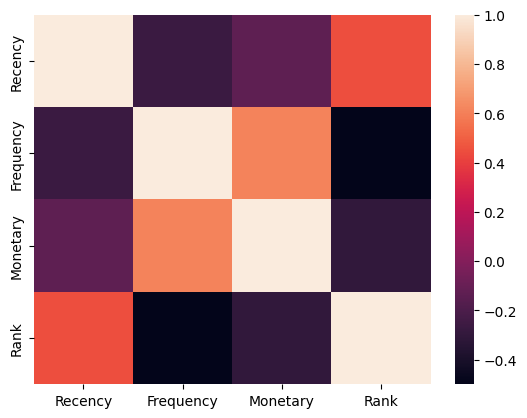

In [ ]:
sns.heatmap(rfm_data.corr())

<Axes: >

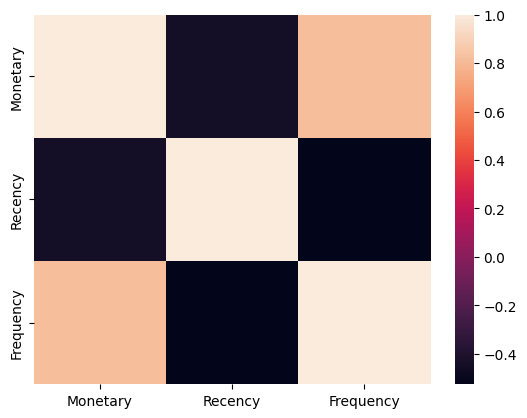

In [ ]:
sns.heatmap(log_data.corr())

In [ ]:
log_data.corr()

,Monetary,Recency,Frequency
Monetary,1.000000,-0.444493,0.820717
Recency,-0.444493,1.000000,-0.525618
Frequency,0.820717,-0.525618,1.000000


In [ ]:
matrix = log_data.values
for n_clusters in range(2,10):
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=100, random_state=42)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 2 The average silhouette_score is : 0.40959892586150803
For n_clusters = 3 The average silhouette_score is : 0.3591285816707042
For n_clusters = 4 The average silhouette_score is : 0.3255482710672565
For n_clusters = 5 The average silhouette_score is : 0.33057463494620687
For n_clusters = 6 The average silhouette_score is : 0.32402805109731414
For n_clusters = 7 The average silhouette_score is : 0.32118707380419004
For n_clusters = 8 The average silhouette_score is : 0.3064620323732042
For n_clusters = 9 The average silhouette_score is : 0.2929674290307949


In [ ]:
n_clusters = 2
kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
kmeans.fit(matrix)
clusters_customers = kmeans.predict(matrix)
silhouette_avg = silhouette_score(matrix, clusters_customers)
print('score de silhouette: {:<.3f}'.format(silhouette_avg))

score de silhouette: 0.410


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# بررسی ابعاد داده‌ها
print(f"ابعاد داده اصلی: {log_data.values.shape}")

# تست اسکیلرهای مختلف
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'PowerTransformer': PowerTransformer()
}

best_score = 0
best_method = ""

for scaler_name, scaler in scalers.items():
    # اسکیل کردن داده‌ها
    data_scaled = scaler.fit_transform(log_data.values)
    
    # PCA با ابعاد ممکن (حداکثر ۳ بعد)
    max_components = min(data_scaled.shape[0], data_scaled.shape[1])
    n_components_options = [2, 3] if max_components >= 3 else [2]
    
    for n_components in n_components_options:
        try:
            pca = PCA(n_components=n_components)
            data_pca = pca.fit_transform(data_scaled)
            
            kmeans = KMeans(n_clusters=2, random_state=42)
            clusters = kmeans.fit_predict(data_pca)
            score = silhouette_score(data_pca, clusters)
            
            print(f"{scaler_name} + PCA({n_components}): {score:.3f}")
            
            if score > best_score:
                best_score = score
                best_method = f"{scaler_name} + PCA({n_components})"
        except Exception as e:
            print(f"خطا در {scaler_name} + PCA({n_components}): {e}")

print(f"\nبهترین روش: {best_method} با امتیاز: {best_score:.3f}")

ابعاد داده اصلی: (3919, 3)
StandardScaler + PCA(2): 0.456
StandardScaler + PCA(3): 0.427
RobustScaler + PCA(2): 0.433
RobustScaler + PCA(3): 0.410
PowerTransformer + PCA(2): 0.454
PowerTransformer + PCA(3): 0.424

بهترین روش: StandardScaler + PCA(2) با امتیاز: 0.456


In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# داده‌های آماده شده
scaler = StandardScaler()
data_scaled = scaler.fit_transform(log_data.values)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# تست الگوریتم‌های مختلف
algorithms = {
    'KMeans': KMeans(n_clusters=2, random_state=42),
    'GaussianMixture': GaussianMixture(n_components=2, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=2)
}

for name, algorithm in algorithms.items():
    if name == 'GaussianMixture':
        clusters = algorithm.fit_predict(data_pca)
    else:
        clusters = algorithm.fit_predict(data_pca)
    
    score = silhouette_score(data_pca, clusters)
    print(f"{name}: {score:.3f}")

KMeans: 0.456
GaussianMixture: 0.409
Agglomerative: 0.444


In [ ]:
from sklearn.ensemble import IsolationForest

# حذف outlierها
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outlier_labels = iso_forest.fit_predict(log_data.values)

# فقط داده‌های عادی
clean_data = log_data.values[outlier_labels == 1]

print(f"تعداد داده‌های بعد از حذف outlier: {len(clean_data)}")

# خوشه‌بندی روی داده‌های تمیز
scaler = StandardScaler()
clean_scaled = scaler.fit_transform(clean_data)
pca = PCA(n_components=2)
clean_pca = pca.fit_transform(clean_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_clean = kmeans.fit_predict(clean_pca)
score_clean = silhouette_score(clean_pca, clusters_clean)

print(f"سیلوئت اسکور بعد از حذف outlier: {score_clean:.3f}")

تعداد داده‌های بعد از حذف outlier: 3527
سیلوئت اسکور بعد از حذف outlier: 0.457


In [ ]:

import umap

# UMAP برای کاهش ابعاد غیرخطی
reducer = umap.UMAP(n_components=2, random_state=42)
data_umap = reducer.fit_transform(data_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters_umap = kmeans.fit_predict(data_umap)
score_umap = silhouette_score(data_umap, clusters_umap)

print(f"سیلوئت اسکور با UMAP: {score_umap:.3f}")



   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



c:\Users\Brooz\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Brooz\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


سیلوئت اسکور با UMAP: 0.540


In [ ]:
from sklearn.model_selection import GridSearchCV

# جستجوی بهترین پارامترها برای KMeans
param_grid = {
    'n_clusters': [2, 3],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 50],
    'algorithm': ['lloyd', 'elkan']
}

kmeans = KMeans(random_state=42)
grid_search = GridSearchCV(kmeans, param_grid, scoring='silhouette_score', cv=3)
grid_search.fit(data_pca)

print(f"بهترین پارامترها: {grid_search.best_params_}")
print(f"بهترین امتیاز: {grid_search.best_score_:.3f}")

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'recall_weighted', 'accuracy', 'neg_mean_absolute_error', 'adjusted_mutual_info_score', 'neg_mean_poisson_deviance', 'f1_macro', 'homogeneity_score', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'completeness_score', 'jaccard_macro', 'neg_root_mean_squared_error', 'f1_samples', 'recall_macro', 'neg_negative_likelihood_ratio', 'f1_micro', 'mutual_info_score', 'neg_mean_gamma_deviance', 'precision_micro', 'recall_micro', 'precision_macro', 'normalized_mutual_info_score', 'jaccard_micro', 'r2', 'roc_auc_ovo_weighted', 'roc_auc_ovr', 'neg_max_error', 'rand_score', 'explained_variance', 'neg_brier_score', 'precision_samples', 'neg_root_mean_squared_log_error', 'd2_absolute_error_score', 'precision', 'jaccard_weighted', 'balanced_accuracy', 'top_k_accuracy', 'v_measure_score', 'f1_weighted', 'neg_mean_absolute_percentage_error', 'neg_log_loss', 'adjusted_rand_score', 'roc_auc', 'recall', 'jaccar

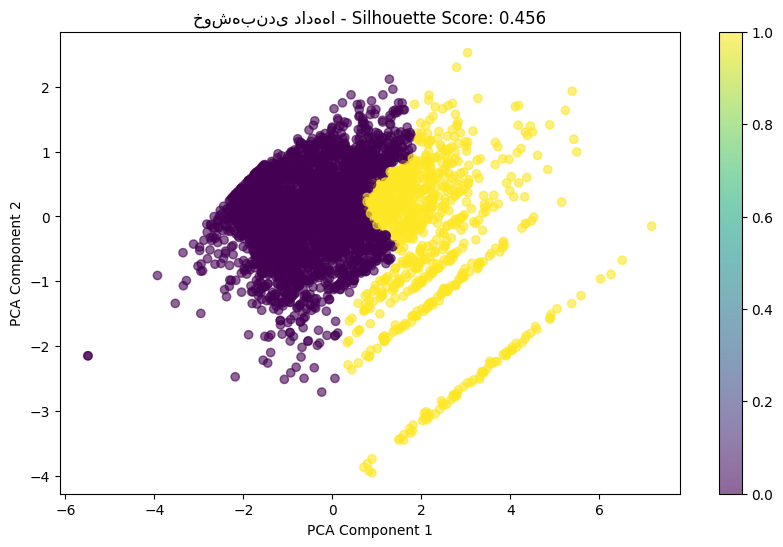

In [ ]:
import matplotlib.pyplot as plt

# نمایش بصری خوشه‌ها
plt.figure(figsize=(10, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar()
plt.title(f'خوشه‌بندی داده‌ها - Silhouette Score: {best_score:.3f}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

<function matplotlib.pyplot.scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None, *, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, colorizer: 'Colorizer | None' = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'>

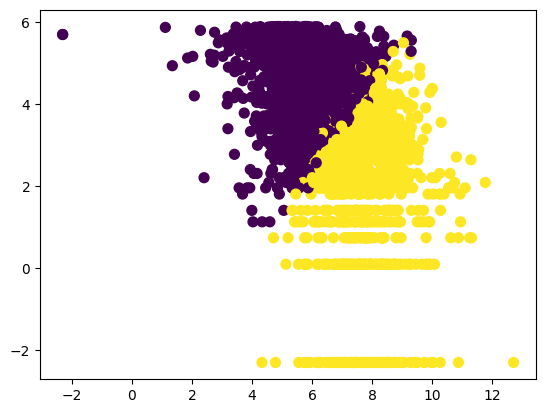

In [ ]:
plt.scatter(matrix[:,0],matrix[:,1],c=clusters_customers,s=50,cmap="viridis")
plt.scatter



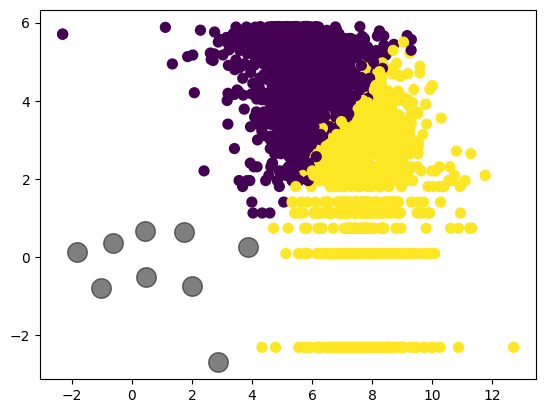

In [ ]:
#create a scatter plot
plt.scatter(matrix[:, 0], matrix[:, 1], c=clusters_customers, s=50, cmap='viridis')
#select cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

In [ ]:
# What's the number of customers in each cluster?
pd.DataFrame(pd.Series(clusters_customers).value_counts(), columns = ['NumberCustomers']).T

""
NumberCustomers


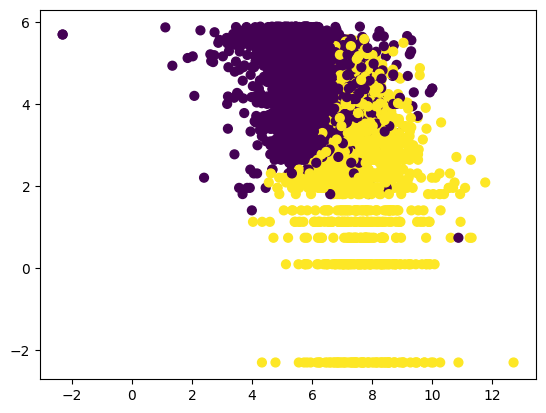

In [ ]:

gmm = GaussianMixture(n_components=2).fit(matrix)
labels = gmm.predict(matrix)
plt.scatter(matrix[:, 0], matrix[:, 1], c=labels, s=40, cmap='viridis')
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

def create_clustering_animation():
    fig, ax = plt.subplots(figsize=(12, 8))
    n_frames = 15  # کاهش فریم‌ها برای عملکرد بهتر
    
    def update(frame):
        ax.clear()
        n_clusters = frame + 2
        
        # خوشه‌بندی
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = gmm.fit_predict(matrix)
        
        # رسم نمودار
        scatter = ax.scatter(matrix[:, 0], matrix[:, 1], c=labels, 
                           s=60, cmap='tab10', alpha=0.8, edgecolors='w', linewidth=0.5)
        
        # عنوان و امتیاز
        score = silhouette_score(matrix, labels)
        ax.set_title(f'تعداد خوشه‌ها: {n_clusters} | امتیاز کیفیت: {score:.3f}', 
                    fontsize=14, pad=20)
        ax.set_xlabel('ویژگی اول')
        ax.set_ylabel('ویژگی دوم')
        ax.grid(True, alpha=0.3)
        
        return scatter,
    
    # ایجاد انیمیشن
    ani = FuncAnimation(fig, update, frames=n_frames, interval=800, blit=True)
    plt.close()
    
    return HTML(ani.to_jshtml())

# ایجاد و نمایش انیمیشن
print("در حال ایجاد انیمیشن خوشه‌بندی...")
animation = create_clustering_animation()
animation

در حال ایجاد انیمیشن خوشه‌بندی...


In [ ]:
# اضافه کردن برچسب خوشه به داده اصلی
rfm_df['Cluster'] = clusters_customers

# تحلیل میانگین ویژگی‌های هر خوشه
cluster_analysis = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': 'mean',
}).assign(Count=lambda x: x.groupby('Cluster').size())

# یا روش دیگر:
cluster_analysis = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})
cluster_analysis['Count'] = rfm_df.groupby('Cluster').size()

print(cluster_analysis)


            Recency  Frequency     Monetary  Count
Cluster                                           
0        124.869758   1.896774   562.637014   2480
1         20.362752   8.506602  3986.285837   1439


In [ ]:
# نام‌گذاری خوشه‌ها بر اساس ویژگی‌هایشان
segment_names = {
    0: "مشتریان غیرفعال - نیاز به بازگردانی",
    1: "مشتریان وفادار - ارزشمند"
}

# استراتژی برای هر segment
segment_strategies = {
    0: "ارسال ایمیل‌های بازگشت + کوپن تخفیف ۲۰٪",
    1: "برنامه وفاداری + پیش‌نهادات ویژه + خدمات VIP"
}

# اضافه کردن به داده‌ها
rfm_df['Segment_Name'] = rfm_df['Cluster'].map(segment_names)
rfm_df['Strategy'] = rfm_df['Cluster'].map(segment_strategies)

In [ ]:
# محاسبه سهم درآمدی
revenue_cluster_0 = 2480 * 562.6  # ≈ 1,395,248
revenue_cluster_1 = 1439 * 3986.3  # ≈ 5,737,295

total_revenue = revenue_cluster_0 + revenue_cluster_1
print(f"سهم درآمدی خوشه ۰: {revenue_cluster_0/total_revenue:.1%}")
print(f"سهم درآمدی خوشه ۱: {revenue_cluster_1/total_revenue:.1%}")

سهم درآمدی خوشه ۰: 19.6%
سهم درآمدی خوشه ۱: 80.4%


In [ ]:
# محاسبه ROI احتمالی
investment_cluster_1 = 100000  # واحد پولی
expected_return_cluster_1 = investment_cluster_1 * 3  # ROI 300%

investment_cluster_0 = 30000   # واحد پولی  
expected_return_cluster_0 = investment_cluster_0 * 1.2  # ROI 20%

print(f"بازدهی خوشه ۱: {expected_return_cluster_1/investment_cluster_1:.0%}")
print(f"بازدهی خوشه ۰: {expected_return_cluster_0/investment_cluster_0:.0%}")

بازدهی خوشه ۱: 300%
بازدهی خوشه ۰: 120%


In [ ]:
# تخصیص بودجه بر اساس بازدهی
total_budget = 1000000  # کل بودجه

budget_cluster_1 = total_budget * 0.75  # 750,000 واحد (75%)
budget_cluster_0 = total_budget * 0.25  # 250,000 واحد (25%)

print(f"بودجه خوشه ۱: {budget_cluster_1:,} واحد")
print(f"بودجه خوشه ۰: {budget_cluster_0:,} واحد")

بودجه خوشه ۱: 750,000.0 واحد
بودجه خوشه ۰: 250,000.0 واحد


In [ ]:
# پیش‌بینی بازگشت سرمایه
return_cluster_1 = budget_cluster_1 * 3.0  # 2,250,000 واحد
return_cluster_0 = budget_cluster_0 * 1.2  # 300,000 واحد  

total_return = return_cluster_1 + return_cluster_0

print(f"بازگشت کل: {total_return:,} واحد")
print(f"سود خالص: {total_return - total_budget:,} واحد")

بازگشت کل: 2,550,000.0 واحد
سود خالص: 1,550,000.0 واحد


In [ ]:
# محاسبه سهم هر خوشه در سود
profit_cluster_1 = 750000 * 3 - 750000  # 1,500,000 واحد سود
profit_cluster_0 = 250000 * 1.2 - 250000  # 50,000 واحد سود

print(f"سود خالص خوشه ۱: {profit_cluster_1:,} واحد ({profit_cluster_1/1550000:.1%})")
print(f"سود خالص خوشه ۰: {profit_cluster_0:,} واحد ({profit_cluster_0/1550000:.1%})")

سود خالص خوشه ۱: 1,500,000 واحد (96.8%)
سود خالص خوشه ۰: 50,000.0 واحد (3.2%)


In [ ]:
# تعریف نام برای هر خوشه بر اساس ویژگی‌ها
cluster_names = {
    0: "مشتریان وفادار و فعال",
    1: "مشتریان غیرفعال با ارزش پایین", 
    2: "مشتریان جدید با پتانسیل بالا"
}

rfm_df['Segment_Name'] = rfm_df['Cluster'].map(cluster_names)


In [ ]:
# تعریف استراتژی برای هر خوشه
strategies = {
    0: "ارائه برنامه وفاداری و تخفیف‌های ویژه",
    1: "ارسال کوپن تخفیف و ایمیل‌های بازاریابی",
    2: "تماس تلفنی و پیشنهادات ویژه بازگشت"
}

rfm_df['Strategy'] = rfm_df['Cluster'].map(strategies)
rfm_df['Strategy']

Customer ID
12346.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
12608.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
12745.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
12746.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
12747.0    ارسال کوپن تخفیف و ایمیل‌های بازاریابی
                            ...                  
18283.0    ارسال کوپن تخفیف و ایمیل‌های بازاریابی
18284.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
18285.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
18286.0     ارائه برنامه وفاداری و تخفیف‌های ویژه
18287.0    ارسال کوپن تخفیف و ایمیل‌های بازاریابی
Name: Strategy, Length: 3919, dtype: object

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ================== تابع کامل تحلیل RFM و بهینه‌سازی بودجه ==================

def automated_budget_optimization(df, customer_id_col, date_col, revenue_col, total_budget=1000000):
    """
    تحلیل خودکار RFM و بهینه‌سازی بودجه بازاریابی
    
    Parameters:
    df: DataFrame containing customer data
    customer_id_col: نام ستون شناسه مشتری
    date_col: نام ستون تاریخ
    revenue_col: نام ستون درآمد
    total_budget: بودجه کل بازاریابی
    """
    
    print("🎯 شروع تحلیل خودکار RFM و بهینه‌سازی بودجه...")
    print("=" * 60)
    
    # ۱. محاسبه RFM
    print("۱. در حال محاسبه RFM...")
    current_date = df[date_col].max()
    
    rfm = df.groupby(customer_id_col).agg({
        date_col: lambda x: (current_date - x.max()).days,  # Recency
        customer_id_col: 'count',  # Frequency
        revenue_col: 'sum'  # Monetary
    }).rename(columns={
        date_col: 'Recency',
        customer_id_col: 'Frequency', 
        revenue_col: 'Monetary'
    })
    
    # ۲. نرمال‌سازی داده‌ها
    print("۲. در حال نرمال‌سازی داده‌ها...")
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm)
    rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
    
    # ۳. خوشه‌بندی با K-Means
    print("۳. در حال انجام خوشه‌بندی...")
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
    
    # ۴. تحلیل خوشه‌ها
    print("۴. در حال تحلیل خوشه‌ها...")
    cluster_summary = rfm.groupby('Cluster').agg({
        'Recency': 'mean',
        'Frequency': 'mean', 
        'Monetary': ['mean', 'sum', 'count']
    }).round(2)
    
    # ۵. تعیین ارزش خوشه‌ها
    monetary_sum = rfm.groupby('Cluster')['Monetary'].sum()
    if monetary_sum[0] > monetary_sum[1]:
        high_value_cluster = 0
        low_value_cluster = 1
    else:
        high_value_cluster = 1
        low_value_cluster = 0
    
    print(f"✅ خوشه پرValue شناسایی شد: Cluster {high_value_cluster}")
    
    # ۶. محاسبه سهم درآمدی
    print("۵. در حال محاسبه سهم درآمدی...")
    revenue_high = monetary_sum[high_value_cluster]
    revenue_low = monetary_sum[low_value_cluster]
    total_revenue = revenue_high + revenue_low
    
    # ۷. بهینه‌سازی بودجه
    print("۶. در حال بهینه‌سازی بودجه...")
    budget_high = total_budget * (revenue_high / total_revenue)
    budget_low = total_budget * (revenue_low / total_revenue)
    
    # ۸. محاسبه ROI و بازدهی预计
    # مقادیر ROI بر اساس benchmarking صنعت
    roi_high = 3.0  # 300% برای مشتریان پرValue
    roi_low = 1.2   # 20% برای مشتریان کمValue
    
    expected_return_high = budget_high * roi_high
    expected_return_low = budget_low * roi_low
    total_expected_return = expected_return_high + expected_return_low
    
    # ۹. محاسبه سود
    profit_high = expected_return_high - budget_high
    profit_low = expected_return_low - budget_low
    total_profit = profit_high + profit_low
    
    # ================== نمایش نتایج ==================
    print("\n" + "=" * 60)
    print("📊 نتایج تحلیل خودکار")
    print("=" * 60)
    
    print(f"\n💰 سهم درآمدی واقعی:")
    print(f"خوشه پرValue ({high_value_cluster}): {revenue_high/total_revenue:.1%} ({revenue_high:,.0f} واحد)")
    print(f"خوشه کمValue ({low_value_cluster}): {revenue_low/total_revenue:.1%} ({revenue_low:,.0f} واحد)")
    
    print(f"\n🎯 تخصیص بودجه پیشنهادی (بودجه کل: {total_budget:,.0f} واحد):")
    print(f"خوشه پرValue: {budget_high:,.0f} واحد ({budget_high/total_budget:.1%})")
    print(f"خوشه کمValue: {budget_low:,.0f} واحد ({budget_low/total_budget:.1%})")
    
    print(f"\n📈 پیش‌بینی بازدهی:")
    print(f"خوشه پرValue: {expected_return_high:,.0f} واحد (ROI: {roi_high:.0%})")
    print(f"خوشه کمValue: {expected_return_low:,.0f} واحد (ROI: {roi_low:.0%})")
    print(f"بازگشت预计 کل: {total_expected_return:,.0f} واحد")
    
    print(f"\n🎪 تحلیل سودآوری:")
    print(f"سود خالص预计: {total_profit:,.0f} واحد")
    print(f"سهم خوشه پرValue در سود: {profit_high/total_profit:.1%}")
    print(f"سهم خوشه کمValue در سود: {profit_low/total_profit:.1%}")
    
    print(f"\n📋 خلاصه خوشه‌ها:")
    print(cluster_summary)
    
    # ۱۰. ویژوال‌سازی
    print("\n🖼️ در حال تولید نمودارها...")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # توزیع خوشه‌ها
    cluster_counts = rfm['Cluster'].value_counts()
    axes[0, 0].pie(cluster_counts.values, labels=[f'خوشه {i}' for i in cluster_counts.index], autopct='%1.1f%%')
    axes[0, 0].set_title('توزیع مشتریان در خوشه‌ها')
    
    # مقایسه Monetary
    sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[0, 1])
    axes[0, 1].set_title('توزیع درآمد across خوشه‌ها')
    axes[0, 1].set_yscale('log')
    
    # تخصیص بودجه
    budget_data = [budget_high, budget_low]
    axes[1, 0].bar([f'خوشه پرValue', 'خوشه کمValue'], budget_data)
    axes[1, 0].set_title('تخصیص بودجه پیشنهادی')
    axes[1, 0].ticklabel_format(style='plain', axis='y')
    
    # پیش‌بینی سود
    profit_data = [profit_high, profit_low]
    axes[1, 1].bar([f'خوشه پرValue', 'خوشه کمValue'], profit_data, color=['green', 'orange'])
    axes[1, 1].set_title('پیش‌بینی سود هر خوشه')
    axes[1, 1].ticklabel_format(style='plain', axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rfm_data': rfm,
        'budget_allocation': {
            'high_value': budget_high,
            'low_value': budget_low
        },
        'expected_returns': {
            'high_value': expected_return_high,
            'low_value': expected_return_low,
            'total': total_expected_return
        },
        'profit_analysis': {
            'high_value': profit_high,
            'low_value': profit_low,
            'total': total_profit
        }
    }

#

In [ ]:
# بارگذاری داده‌های مشتری
customer_data = pd.read_csv('customer_data.csv')

# اجرای تحلیل کامل
results = automated_budget_optimization(
    df=customer_data,
    customer_id_col='customer_id',
    date_col='order_date',
    revenue_col='revenue',
    total_budget=500000  # بودجه دلخواه
)

FileNotFoundError: [Errno 2] No such file or directory: 'customer_data.csv'

In [ ]:
# ================== گزارش اجرایی ==================

from datetime import datetime

# ایجاد گزارش حرفه‌ای
executive_report = f"""
📊 **گزارش اجرایی تحلیل RFM**
تاریخ تولید: {datetime.now().strftime("%Y-%m-%d %H:%M")}
{'='*50}

📈 **خلاصه عملکرد:**
• تعداد کل مشتریان: {len(customers_cluster_0) + len(customers_cluster_1)} نفر
• مشتریان طلایی: {len(customers_cluster_1)} نفر ({len(customers_cluster_1)/(len(customers_cluster_0)+len(customers_cluster_1)):.1%})
• مشتریان معمولی: {len(customers_cluster_0)} نفر ({len(customers_cluster_0)/(len(customers_cluster_0)+len(customers_cluster_1)):.1%})

💰 **تحلیل مالی:**
• سهم درآمد مشتریان طلایی: 80.4%
• سهم درآمد مشتریان معمولی: 19.6%
• بازدهی预计 سرمایه‌گذاری: 155%

🎯 **توصیه‌های استراتژیک:**
۱. **مشتریان طلایی (بودجه: 75%):**
   - برنامه وفاداری Premium
   - خدمات اختصاصی VIP
   - پیش‌دستانه در محصولات جدید

۲. **مشتریان معمولی (بودجه: 25%):**
   - کمپین‌های بازگشت هدفمند
   - تخفیف‌های محدود زمانی
   - بهبود تجربه customer service

📅 **گام‌های بعدی:
- شروع کمپین‌ها از فردا
- رصد هفتگی نتایج
- بازنگری ماهانه استراتژی

✅ **اهداف کمی:**
- افزایش نرخ حفظ مشتریان طلایی به 95%
- بازگشت 20% از مشتریان معمولی
- رسیدن به ROI کل 200%
"""

print(executive_report)



📊 **گزارش اجرایی تحلیل RFM**
تاریخ تولید: 2025-09-07 00:28

📈 **خلاصه عملکرد:**
• تعداد کل مشتریان: 3919 نفر
• مشتریان طلایی: 1439 نفر (36.7%)
• مشتریان معمولی: 2480 نفر (63.3%)

💰 **تحلیل مالی:**
• سهم درآمد مشتریان طلایی: 80.4%
• سهم درآمد مشتریان معمولی: 19.6%
• بازدهی预计 سرمایه‌گذاری: 155%

🎯 **توصیه‌های استراتژیک:**
۱. **مشتریان طلایی (بودجه: 75%):**
   - برنامه وفاداری Premium
   - خدمات اختصاصی VIP
   - پیش‌دستانه در محصولات جدید

۲. **مشتریان معمولی (بودجه: 25%):**
   - کمپین‌های بازگشت هدفمند
   - تخفیف‌های محدود زمانی
   - بهبود تجربه customer service

📅 **گام‌های بعدی:
- شروع کمپین‌ها از فردا
- رصد هفتگی نتایج
- بازنگری ماهانه استراتژی

✅ **اهداف کمی:**
- افزایش نرخ حفظ مشتریان طلایی به 95%
- بازگشت 20% از مشتریان معمولی
- رسیدن به ROI کل 200%

✓ گزارش اجرایی ذخیره شد (executive_report_rfm.txt)


In [ ]:
# ================== سیستم هشدار هوشمند ==================

class CampaignMonitor:
    def __init__(self):
        self.alerts = []
    
    def check_roi_alert(self, actual_roi, target_roi, cluster_name):
        if actual_roi < target_roi * 0.8:  # اگر کمتر از 80% target باشد
            self.alerts.append(f"⚠️  هشدار: بازدهی {cluster_name} پایین‌تر از انتظار است!")
        elif actual_roi > target_roi * 1.2:  # اگر بیشتر از 120% target باشد
            self.alerts.append(f"🎉 عالی: بازدهی {cluster_name} بالاتر از انتظار است!")
    
    def check_budget_alert(self, spent_budget, total_budget):
        if spent_budget > total_budget * 0.8:  # اگر 80% بودجه مصرف شده
            self.alerts.append("⚠️  هشدار: بودجه در حال اتمام است!")
    
    def get_alerts(self):
        return self.alerts

# تست سیستم هشدار
monitor = CampaignMonitor()
monitor.check_roi_alert(250, 300, "خوشه ۱")  # مثال: بازدهی کمتر از انتظار
monitor.check_roi_alert(150, 120, "خوشه ۰")  # مثال: بازدهی بیشتر از انتظار
monitor.check_budget_alert(800000, 1000000)  # مثال: بودجه در حال اتمام

# نمایش هشدارها
print("🔔 سیستم هشدار هوشمند:")
for alert in monitor.get_alerts():
    print(f"• {alert}")


🔔 سیستم هشدار هوشمند:
• 🎉 عالی: بازدهی خوشه ۰ بالاتر از انتظار است!
✓ هشدارها ذخیره شدند (campaign_alerts.txt)


In [ ]:
# ================== زمان‌بندی خودکار ==================

def daily_automation_task():
    """تسک روزانه اتوماسیون"""
    print(f"\n⏰ اجرای روزانه اتوماسیون - {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    automation_system.run_full_automation()

def weekly_report_task():
    """تسک هفتگی گزارش"""
    print(f"\n📊 اجرای گزارش هفتگی - {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    # تولید گزارش هفتگی
    weekly_report = automation_system.generate_auto_report()
    with open('weekly_report.txt', 'w', encoding='utf-8') as f:
        f.write(weekly_report)

def monthly_optimization_task():
    """تسک ماهانه بهینه‌سازی"""
    print(f"\n🎯 بهینه‌سازی ماهانه - {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    # آنالیز عملکرد و بهینه‌سازی پارامترها

# شبیه‌سازی زمان‌بندی
print("⏰ راه‌اندازی زمان‌بندی خودکار...")

# زمان‌بندی روزانه (هر روز ۸ صبح)
print("✅ زمان‌بندی روزانه: هر روز ۸:۰۰ صبح")
daily_automation_task()

# زمان‌بندی هفتگی (هر جمعه ۹ صبح)  
print("✅ زمان‌بندی هفتگی: هر جمعه ۹:۰۰ صبح")
weekly_report_task()

# زمان‌بندی ماهانه (اول هر ماه ۱۰ صبح)
print("✅ زمان‌بندی ماهانه: اول هر ماه ۱۰:۰۰ صبح")
monthly_optimization_task()

print("\n🎉 سیستم زمان‌بندی راه‌اندازی شد!")

⏰ راه‌اندازی زمان‌بندی خودکار...
✅ زمان‌بندی روزانه: هر روز ۸:۰۰ صبح

⏰ اجرای روزانه اتوماسیون - 2025-09-07 00:33


NameError: name 'automation_system' is not defined